### Missing Value Analysis and feature engineering prior to visual EDA

This notebook documents the preparatory steps before visual EDA, time-series EDA and feature engineering & model-building.

In [28]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import openpyxl


In [29]:
# Load finalized data
df = pd.read_csv('../../data/processed/data_finalized.csv', 
                 encoding='cp1252',  # to account for regional data settings
                 parse_dates=['date_dt']) # data is csv, date_dt needs to be parsed as date on loading

In [30]:
#Setup
meta_lib_path = '../../data/metadata/meta_data_library.xlsx'
all = ['2000-01-01', '2025-12-31']
main = ['2020-01-01', '2025-12-31']
corona = ['2020-03-01', '2021-12-31']
energy_crisis = ['2022-01-01', '2023-12-31']

In [31]:
"""
EDA Visualization Functions for Energy Market Analysis v1
Clean reimplementation
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.dates import MonthLocator, DateFormatter

# Set style
sns.set_style("whitegrid", {"grid.alpha": 0.11})

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def load_meta_labels(meta_path):
    """Load label and unit mappings from meta_data_library."""
    from pathlib import Path
    
    file_ext = Path(meta_path).suffix.lower()
    
    try:
        if file_ext in ['.xlsx', '.xls']:
            meta = pd.read_excel(meta_path)
        else:
            encodings = ['utf-8', 'cp1252', 'iso-8859-1']
            delimiters = [',', ';']
            meta = None
            for encoding in encodings:
                for delimiter in delimiters:
                    try:
                        meta = pd.read_csv(meta_path, encoding=encoding, delimiter=delimiter)
                        if len(meta.columns) >= 2:
                            break
                    except:
                        continue
                if meta is not None and len(meta.columns) >= 2:
                    break
            if meta is None:
                raise Exception("Could not read file")
        
        label_dict = dict(zip(meta['column'], meta['label']))
        unit_dict = dict(zip(meta['column'], meta['unit']))
        return label_dict, unit_dict
        
    except Exception as e:
        print(f"Warning: Could not load meta_data_library: {e}")
        return {}, {}

def get_label(column, label_dict):
    """Get label for column or return column name as fallback."""
    if column in label_dict:
        return label_dict[column]
    else:
        print(f"Warning: meta_data_library incomplete. Displaying column name instead: {column}")
        return column

def get_unit(column, unit_dict):
    """Get unit for column or return empty string as fallback."""
    if column in unit_dict:
        unit = unit_dict[column]
        return unit if pd.notna(unit) else ""
    return ""

def format_date_ym(date_str):
    """Format date string to YYYY-MM."""
    return date_str[:7]

# =============================================================================
# PLOT FUNCTIONS
# =============================================================================

def single_plot(df, column, time_window, aggregation_level, meta_library_path,
                figsize=(12, 6)):
    """Plot single time series variable."""
    
    # Load metadata
    label_dict, unit_dict = load_meta_labels(meta_library_path)
    label = get_label(column, label_dict)
    unit = get_unit(column, unit_dict)
    
    # Filter and prepare data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    df_filtered['date_dt'] = pd.to_datetime(df_filtered['date_dt'])
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df_filtered['date_dt'], df_filtered[column], linewidth=2)
    
    # Titles and labels
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    ax.set_title(f"{label} Time Plot {start_ym} to {end_ym}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel(unit if unit else label, fontsize=12)
    
    # Format x-axis
    ax.xaxis.set_major_locator(MonthLocator(bymonth=[3, 6, 9, 12]))
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Grid
    ax.grid(True, alpha=0.11)
    
    plt.tight_layout()
    plt.show()


def dual_axis_plot(df, primary_columns, secondary_columns, time_window, aggregation_level,
                   meta_library_path, figsize=(12, 7)):
    """Plot multiple variables on dual y-axes with legend below."""
    
    # Load metadata
    label_dict, unit_dict = load_meta_labels(meta_library_path)
    
    # Filter and prepare data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    df_filtered['date_dt'] = pd.to_datetime(df_filtered['date_dt'])
    
    # Create figure with GridSpec: plot area + legend area
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 1, height_ratios=[8, 1], hspace=0.3)
    
    # Main plot
    ax1 = fig.add_subplot(gs[0])
    ax2 = ax1.twinx()
    
    # Plot primary (left axis)
    for col in primary_columns:
        label = get_label(col, label_dict)
        ax1.plot(df_filtered['date_dt'], df_filtered[col], label=label, linewidth=2)
    
    # Plot secondary (right axis)
    for col in secondary_columns:
        label = get_label(col, label_dict)
        ax2.plot(df_filtered['date_dt'], df_filtered[col], label=label, 
                linewidth=2, linestyle='--')
    
    # Titles and labels
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    ax1.set_title(f"Combined Time Plot {start_ym} to {end_ym}", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Date", fontsize=12)
    
    primary_unit = get_unit(primary_columns[0], unit_dict)
    secondary_unit = get_unit(secondary_columns[0], unit_dict)
    ax1.set_ylabel(primary_unit if primary_unit else "Primary Axis", fontsize=12)
    ax2.set_ylabel(secondary_unit if secondary_unit else "Secondary Axis", fontsize=12)
    
    # Format x-axis
    ax1.xaxis.set_major_locator(MonthLocator(bymonth=[3, 6, 9, 12]))
    ax1.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Grid
    ax1.grid(True, alpha=0.11)
    
    # Legend in separate area below
    ax_legend = fig.add_subplot(gs[1])
    ax_legend.axis('off')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax_legend.legend(lines1 + lines2, labels1 + labels2, 
                    loc='center', ncol=3, frameon=True)
    
    plt.show()


def standard_axis_plot(df, columns, time_window, aggregation_level, meta_library_path,
                      figsize=(12, 7)):
    """Plot multiple variables with 0-100 normalization and legend below."""
    
    # Load metadata
    label_dict, unit_dict = load_meta_labels(meta_library_path)
    
    # Filter and prepare data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    df_filtered['date_dt'] = pd.to_datetime(df_filtered['date_dt'])
    
    # Create figure with GridSpec: plot area + legend area
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 1, height_ratios=[8, 1], hspace=0.3)
    
    # Main plot
    ax = fig.add_subplot(gs[0])
    
    # Normalize and plot each column
    for col in columns:
        col_data = df_filtered[col].dropna()
        if len(col_data) > 0:
            col_min = col_data.min()
            col_max = col_data.max()
            if col_max - col_min > 0:
                normalized = ((df_filtered[col] - col_min) / (col_max - col_min)) * 100
            else:
                normalized = df_filtered[col] * 0
            
            label = get_label(col, label_dict)
            ax.plot(df_filtered['date_dt'], normalized, label=label, linewidth=2)
    
    # Titles and labels
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    ax.set_title(f"Combined Time Plot {start_ym} to {end_ym}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Normalized Scale (0-100)", fontsize=12)
    ax.set_ylim(-5, 105)
    
    # Format x-axis
    ax.xaxis.set_major_locator(MonthLocator(bymonth=[3, 6, 9, 12]))
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Grid
    ax.grid(True, alpha=0.11)
    
    # Legend in separate area below
    ax_legend = fig.add_subplot(gs[1])
    ax_legend.axis('off')
    
    lines, labels = ax.get_legend_handles_labels()
    ax_legend.legend(lines, labels, loc='center', ncol=3, frameon=True)
    
    plt.show()


# Example usage
"""
# Load data
df = pd.read_csv('../data/processed/data_finalized.csv', parse_dates=['date_dt'])

# Define paths and time windows
meta_lib_path = '../data/metadata/meta_data_library.xlsx'
main = ['2020-01-01', '2023-12-31']

# Single plot
single_plot(df, 'price_exaa_mean', main, 'monthly', meta_lib_path)

# Dual axis plot
dual_axis_plot(df, ['price_exaa_mean'], ['carbonprices_primary_market'],
               main, 'monthly', meta_lib_path)

# Standard axis plot
standard_axis_plot(df, ['price_exaa_mean', 'carbonprices_primary_market'],
                   main, 'monthly', meta_lib_path)
"""

"\n# Load data\ndf = pd.read_csv('../data/processed/data_finalized.csv', parse_dates=['date_dt'])\n\n# Define paths and time windows\nmeta_lib_path = '../data/metadata/meta_data_library.xlsx'\nmain = ['2020-01-01', '2023-12-31']\n\n# Single plot\nsingle_plot(df, 'price_exaa_mean', main, 'monthly', meta_lib_path)\n\n# Dual axis plot\ndual_axis_plot(df, ['price_exaa_mean'], ['carbonprices_primary_market'],\n               main, 'monthly', meta_lib_path)\n\n# Standard axis plot\nstandard_axis_plot(df, ['price_exaa_mean', 'carbonprices_primary_market'],\n                   main, 'monthly', meta_lib_path)\n"

##### Maximising Electricity Price Data Availability for Analysis and Modeling

`price_exaa_mean` and `price_mc_auction_mean` experience significant overlap between 2020-12 and 2022-12, while extending backwards and forwards. In the period of overlap, their monthly are almost identical.

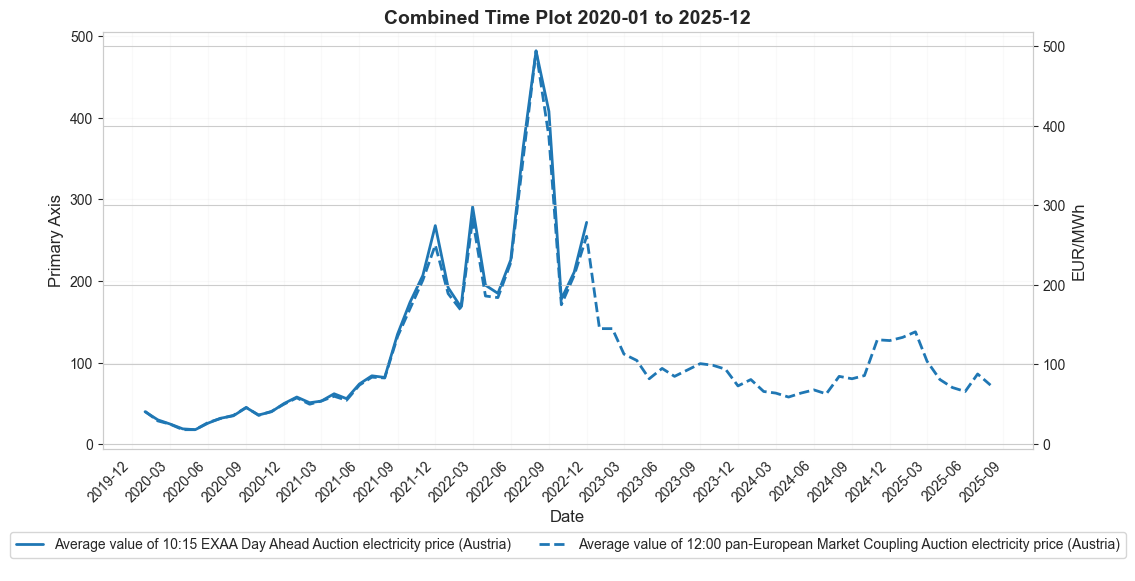

In [32]:
# Demonstrating overlap of price_exaa_mean and price_mc_auction_mean
dual_axis_plot(df, ['price_exaa_mean'], ['price_mc_auction_mean'],
               main, 'monthly', meta_lib_path)


In [33]:
overlap = df[(df['price_exaa_mean'].notna()) & (df['price_mc_auction_mean'].notna())]
print("Correlation between price_exaa_mean and price_mc_auction_mean in overlapping periods")
print(overlap[['price_exaa_mean', 'price_mc_auction_mean']].corr())
print(20*"-")
print("")
print("Desciptive statistics for overlapping periods")
print(overlap[['price_exaa_mean', 'price_mc_auction_mean']].describe())

Correlation between price_exaa_mean and price_mc_auction_mean in overlapping periods
                       price_exaa_mean  price_mc_auction_mean
price_exaa_mean               1.000000               0.993711
price_mc_auction_mean         0.993711               1.000000
--------------------

Desciptive statistics for overlapping periods
       price_exaa_mean  price_mc_auction_mean
count      1291.000000            1291.000000
mean        135.553060             133.569326
std         127.762307             126.729262
min          -5.000000             -23.000000
25%          39.500000              39.000000
50%          76.000000              76.000000
75%         199.000000             199.000000
max         727.000000             764.000000


To maximise the amount of available data for analysis, a new feature is created `price_combined`, which consists of `price_exaa_mean` and `price_mc_auction_mean`only where only these prices are available and a mean of these two price signals where overlap exists.

In [34]:
# Averaging Overlap
def create_combined_price(row):
    exaa = row['price_exaa_mean']
    mc = row['price_mc_auction_mean']
    
    if pd.notna(exaa) and pd.notna(mc):
        return (exaa + mc) / 2  # Overlap: average
    elif pd.notna(exaa):
        return exaa  # only EXAA
    else:
        return mc  # only MC

df['price_combined'] = df.apply(create_combined_price, axis=1)

In [35]:
df.info()  # Check new column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 61 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  4663 non-null   object        
 1   year                                  4663 non-null   float64       
 2   month                                 4663 non-null   float64       
 3   quarter                               4663 non-null   float64       
 4   week                                  4663 non-null   float64       
 5   aggregation_level                     4663 non-null   object        
 6   price_exaa_mean                       3440 non-null   float64       
 7   price_mc_auction_mean                 2439 non-null   float64       
 8   price_count_exaa                      4590 non-null   float64       
 9   price_count_mc                        4590 non-null   float64       
 10  

##### Creating a column "renewables as percent of total electricity generation"
One goal of this project is to discover the impact that electricity production from renewable sources in Austria have on electricity prices. Therefore new variables are created: 
- `prod_renewable` = Sum of electricity produced using hydropower, biomass, wind, photovoltaics but NOT geothermal (this makes up very little of total power production and is available for fewer months than the other data sources)
- `prod_non_renewable` = Sum of electricity produced fossil thermal power plants and other fuel sources.
- `prod_renewables_pct_total` = Percentage of electricity generated using renewable sources in the total electricity generated.

IMPORTANT: 
For comparison to the offical data, see `https://www.e-control.at/statistik/e-statistik/charts/str_ges_neu_erz`- geothermal power is included there, so differences to official data may occur

In [36]:
df['prod_renewable'] = df[['prod_hydropower_production_total',
                           'prod_renewable_bio_production',
                           'prod_renewable_SoBio_production',
                           'prod_wind_total',
                           'prod_pv_total',
                           ]].sum(axis=1, skipna=True) 

df['prod_non_renewable'] = df[['prod_fossil_subtotal_production',
                           'prod_other_fuels_production',
                           ]].sum(axis=1, skipna=True)

df['prod_total'] = df[['prod_renewable',
                           'prod_non_renewable',
                           ]].sum(axis=1, skipna=True)


df['prod_renewables_pct_total'] = (df['prod_renewable'] / df['prod_total']) * 100

In [37]:
# ============================================================================
# FIX: Production Mix Features - Correct NaN Handling
# ============================================================================

def safe_sum_with_nan(df, columns):
    """
    Sum columns but return NaN if ALL input columns are NaN.
    Prevents false zeros at data boundaries.
    """
    subset = df[columns]
    return subset.sum(axis=1).where(subset.notna().any(axis=1))


# Recalculate production features with correct NaN propagation
df['prod_renewable'] = safe_sum_with_nan(df, [
    'prod_hydropower_production_total',
    'prod_renewable_bio_production',
    'prod_renewable_SoBio_production',
    'prod_wind_total',
    'prod_pv_total'
])

df['prod_non_renewable'] = safe_sum_with_nan(df, [
    'prod_fossil_subtotal_production',
    'prod_other_fuels_production'
])

df['prod_total'] = safe_sum_with_nan(df, [
    'prod_renewable',
    'prod_non_renewable'
])

df['prod_renewables_pct_total'] = (df['prod_renewable'] / df['prod_total']) * 100


# ============================================================================
# VALIDATION: Check for false zeros
# ============================================================================

print("PROD FEATURES - NaN vs Zero Check:")
print("-" * 50)

for col in ['prod_renewable', 'prod_non_renewable', 'prod_total', 'prod_renewables_pct_total']:
    zero_count = (df[col] == 0).sum()
    nan_count = df[col].isna().sum()
    total = len(df)
    
    print(f"{col}:")
    print(f"  Zeros: {zero_count} ({zero_count/total*100:.1f}%)")
    print(f"  NaNs:  {nan_count} ({nan_count/total*100:.1f}%)")
    print()

# Show first/last rows to verify boundary behavior
print("\nFirst 5 rows (boundary check):")
print(df[['date', 'prod_renewable', 'prod_non_renewable', 'prod_total']].head())
print("\nLast 5 rows (boundary check):")
print(df[['date', 'prod_renewable', 'prod_non_renewable', 'prod_total']].tail())

PROD FEATURES - NaN vs Zero Check:
--------------------------------------------------
prod_renewable:
  Zeros: 0 (0.0%)
  NaNs:  4476 (96.0%)

prod_non_renewable:
  Zeros: 0 (0.0%)
  NaNs:  4476 (96.0%)

prod_total:
  Zeros: 0 (0.0%)
  NaNs:  4476 (96.0%)

prod_renewables_pct_total:
  Zeros: 0 (0.0%)
  NaNs:  4476 (96.0%)


First 5 rows (boundary check):
         date  prod_renewable  prod_non_renewable  prod_total
0  2009-01-01             NaN                 NaN         NaN
1  2009-02-01             NaN                 NaN         NaN
2  2009-03-01             NaN                 NaN         NaN
3  2009-04-01             NaN                 NaN         NaN
4  2009-05-01             NaN                 NaN         NaN

Last 5 rows (boundary check):
            date  prod_renewable  prod_non_renewable  prod_total
4658  2025-08-29             NaN                 NaN         NaN
4659  2025-08-30             NaN                 NaN         NaN
4660  2025-08-31             NaN             

In [38]:
df.info()  # Check new columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 65 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  4663 non-null   object        
 1   year                                  4663 non-null   float64       
 2   month                                 4663 non-null   float64       
 3   quarter                               4663 non-null   float64       
 4   week                                  4663 non-null   float64       
 5   aggregation_level                     4663 non-null   object        
 6   price_exaa_mean                       3440 non-null   float64       
 7   price_mc_auction_mean                 2439 non-null   float64       
 8   price_count_exaa                      4590 non-null   float64       
 9   price_count_mc                        4590 non-null   float64       
 10  

##### Missing Value Analysis and determining data range to be used in analysis

The data pipeline was specified to include as much data as possible to allow for different kinds of practical excercises and analyses. 

For the purpose of this project, the time series length will be truncated to fit the maximum extent of available data.

<Axes: >

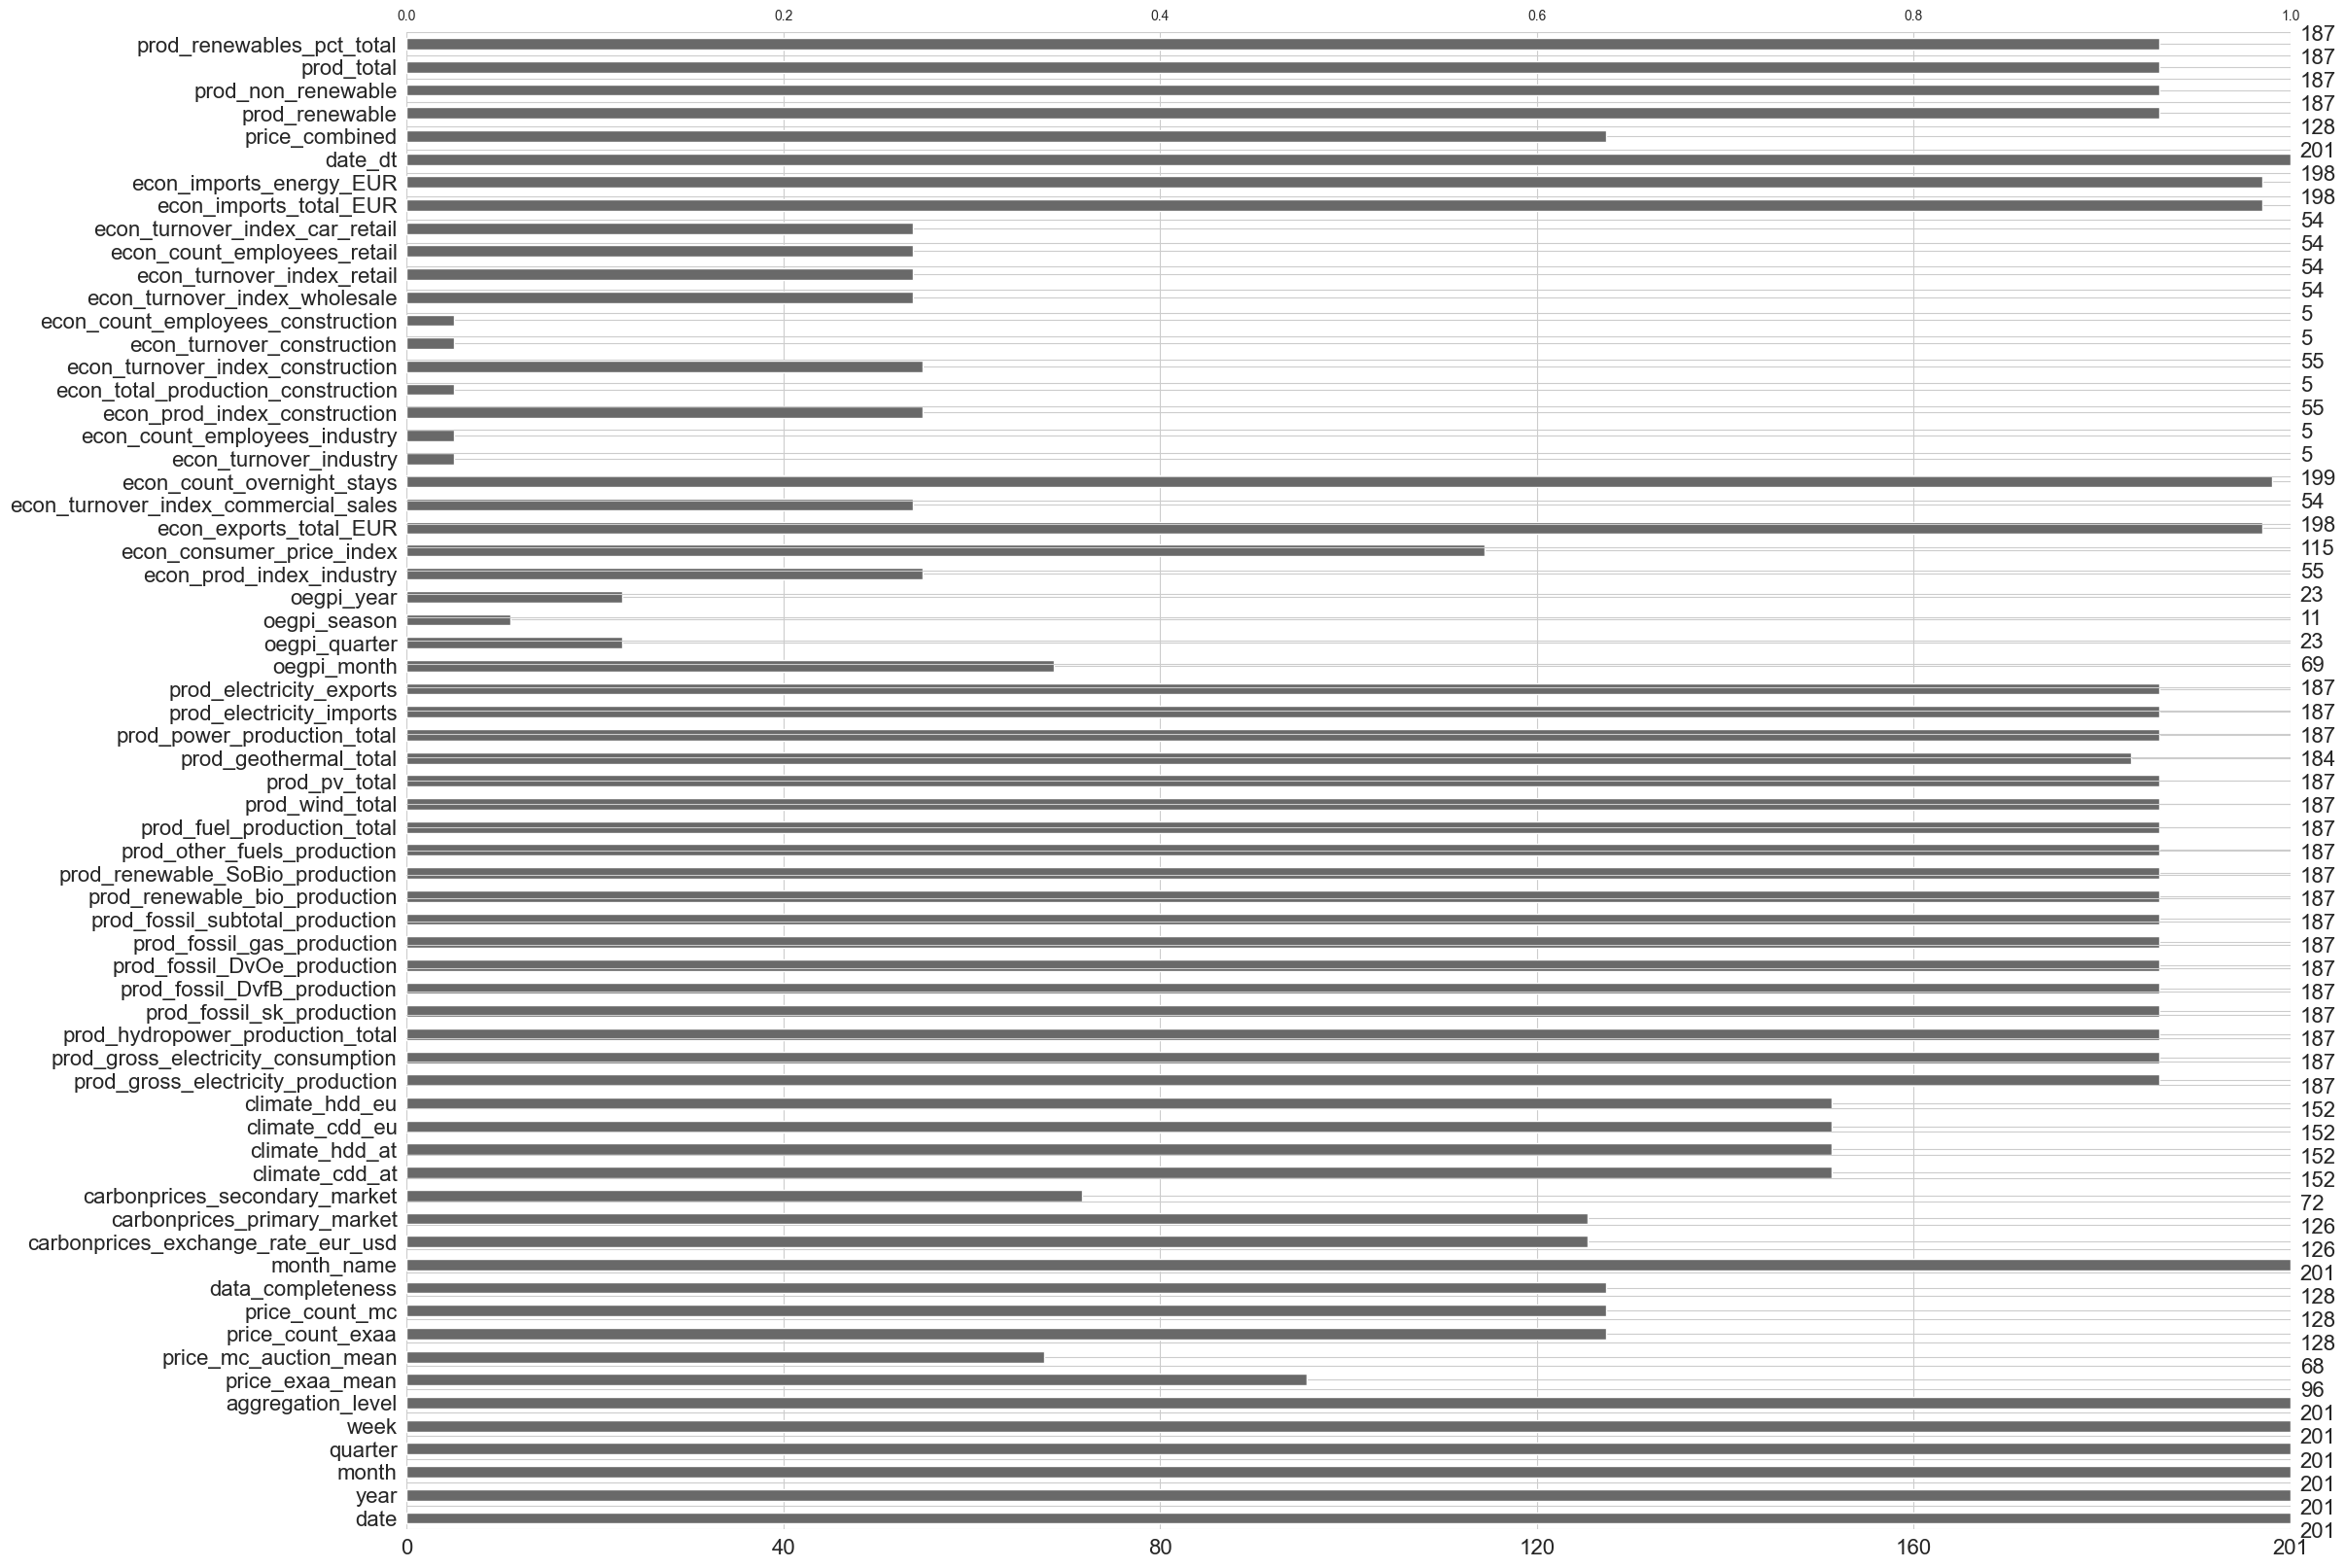

In [39]:
#determine initial missing value patterns
import missingno as msno


df_monthly = df[df['aggregation_level'] == 'monthly']

# 4 Plots schnell durchlaufen

msno.bar(df_monthly)


The central variable "price_combined" is available only for 128 out of 201 total months in the data.  Also there are a series of variables that contain data only from recent months. 

Data will be truncated around "price_combined" and the variables following variables dropped before visual EDA: `oegpi_quarter`,`oegpi_season`, `oegpi_year`, `econ_count_employees_industry`, `econ_turnover_industry`, `econ_total_production_construction`, `econ_turnover_construction`,`econ_count_employees_construction`

In [40]:
#determine initial missing value patterns
import missingno as msno

df_length_price = df[
    (df['aggregation_level'] == 'monthly') & 
    (df['price_combined'].notna())
].copy()

df_length_price = df_length_price.sort_values('date_dt').reset_index(drop=True)

print("="*70)
print("DATASET REDUCTION TO PRICE_COMBINED AVAILABILITY")
print("="*70)
print(f"\nOriginal monthly observations: {len(df[df['aggregation_level'] == 'monthly'])}")
print(f"After filtering for price_combined: {len(df_length_price)}")
print(f"Removed: {len(df[df['aggregation_level'] == 'monthly']) - len(df_length_price)} months")
print()
print(f"Analysis period: {df_length_price['date_dt'].min().strftime('%Y-%m')} to {df_length_price['date_dt'].max().strftime('%Y-%m')}")
print(f"Duration: {len(df_length_price)} months")
print()

DATASET REDUCTION TO PRICE_COMBINED AVAILABILITY

Original monthly observations: 201
After filtering for price_combined: 128
Removed: 73 months

Analysis period: 2015-01 to 2025-08
Duration: 128 months



In [41]:
date_range = pd.date_range(
    start=df_length_price['date_dt'].min(), 
    end=df_length_price['date_dt'].max(), 
    freq='MS'
)
expected_months = len(date_range)

In [42]:
expected_months == len(df_length_price)  # Should be True if no months are missing

True

In [43]:

cols_to_drop = ['oegpi_quarter',
                 'oegpi_season',
                   'oegpi_year',
                   'econ_count_employees_industry',
                   'econ_turnover_industry',
                   'econ_total_production_construction',
                   'econ_turnover_construction',
                   'econ_count_employees_construction'] #dropped columns are included in data for completeness, but not used
df_reduced = df_length_price[df_length_price['aggregation_level'] == 'monthly'].drop(columns=cols_to_drop)

# looking at each data source separately for better overview

df_price= df_reduced.filter(like='price_') #electricity prices from exaa and mc auction only

df_carbon= df_reduced.filter(like='carbonprices_') #carbon prices from icap only

df_climate= df_reduced.filter(like='climate_') #hdd and cdd from EUROSTAT only

df_prod = df_reduced.filter(like='prod_') #production data from E-Control only

df_econ= df_reduced.filter(like='econ_') #economic data from Statistik Austria only





<Axes: >

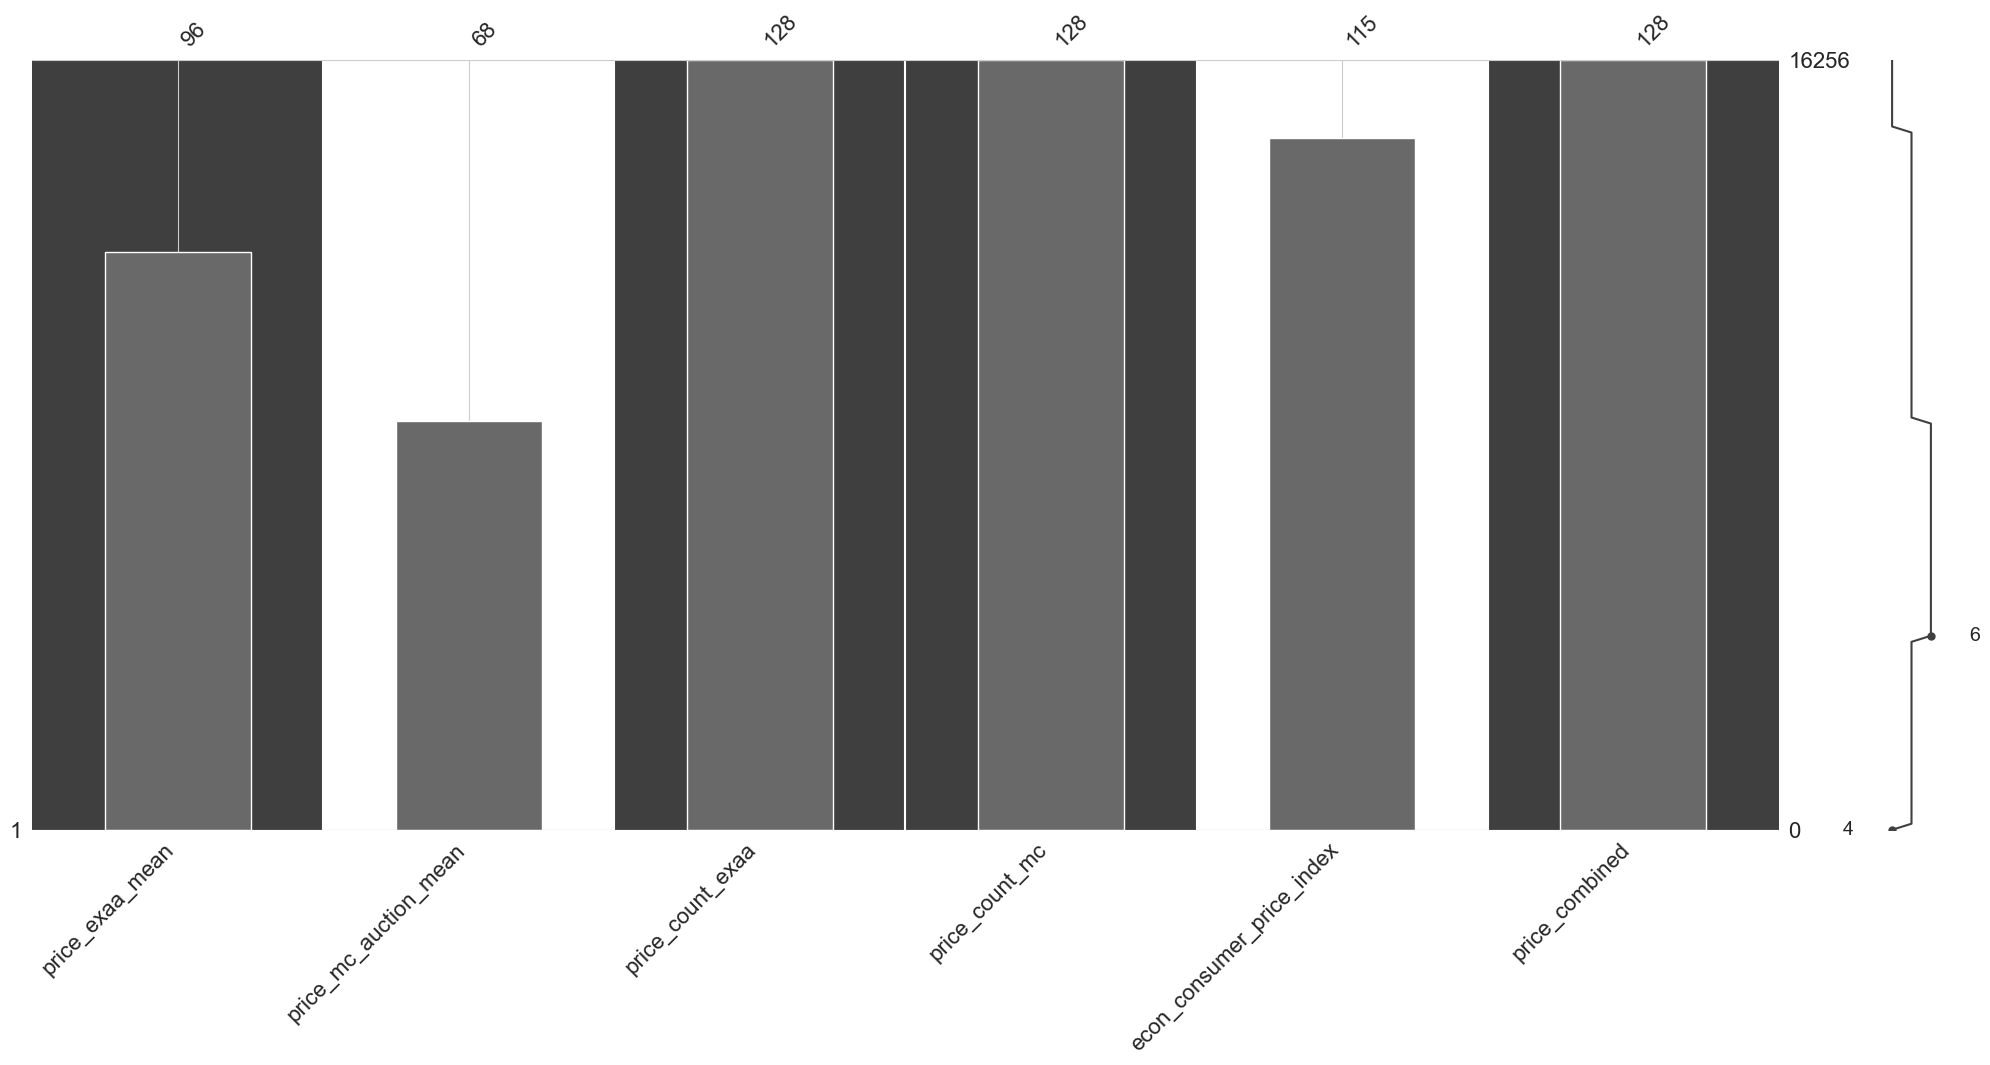

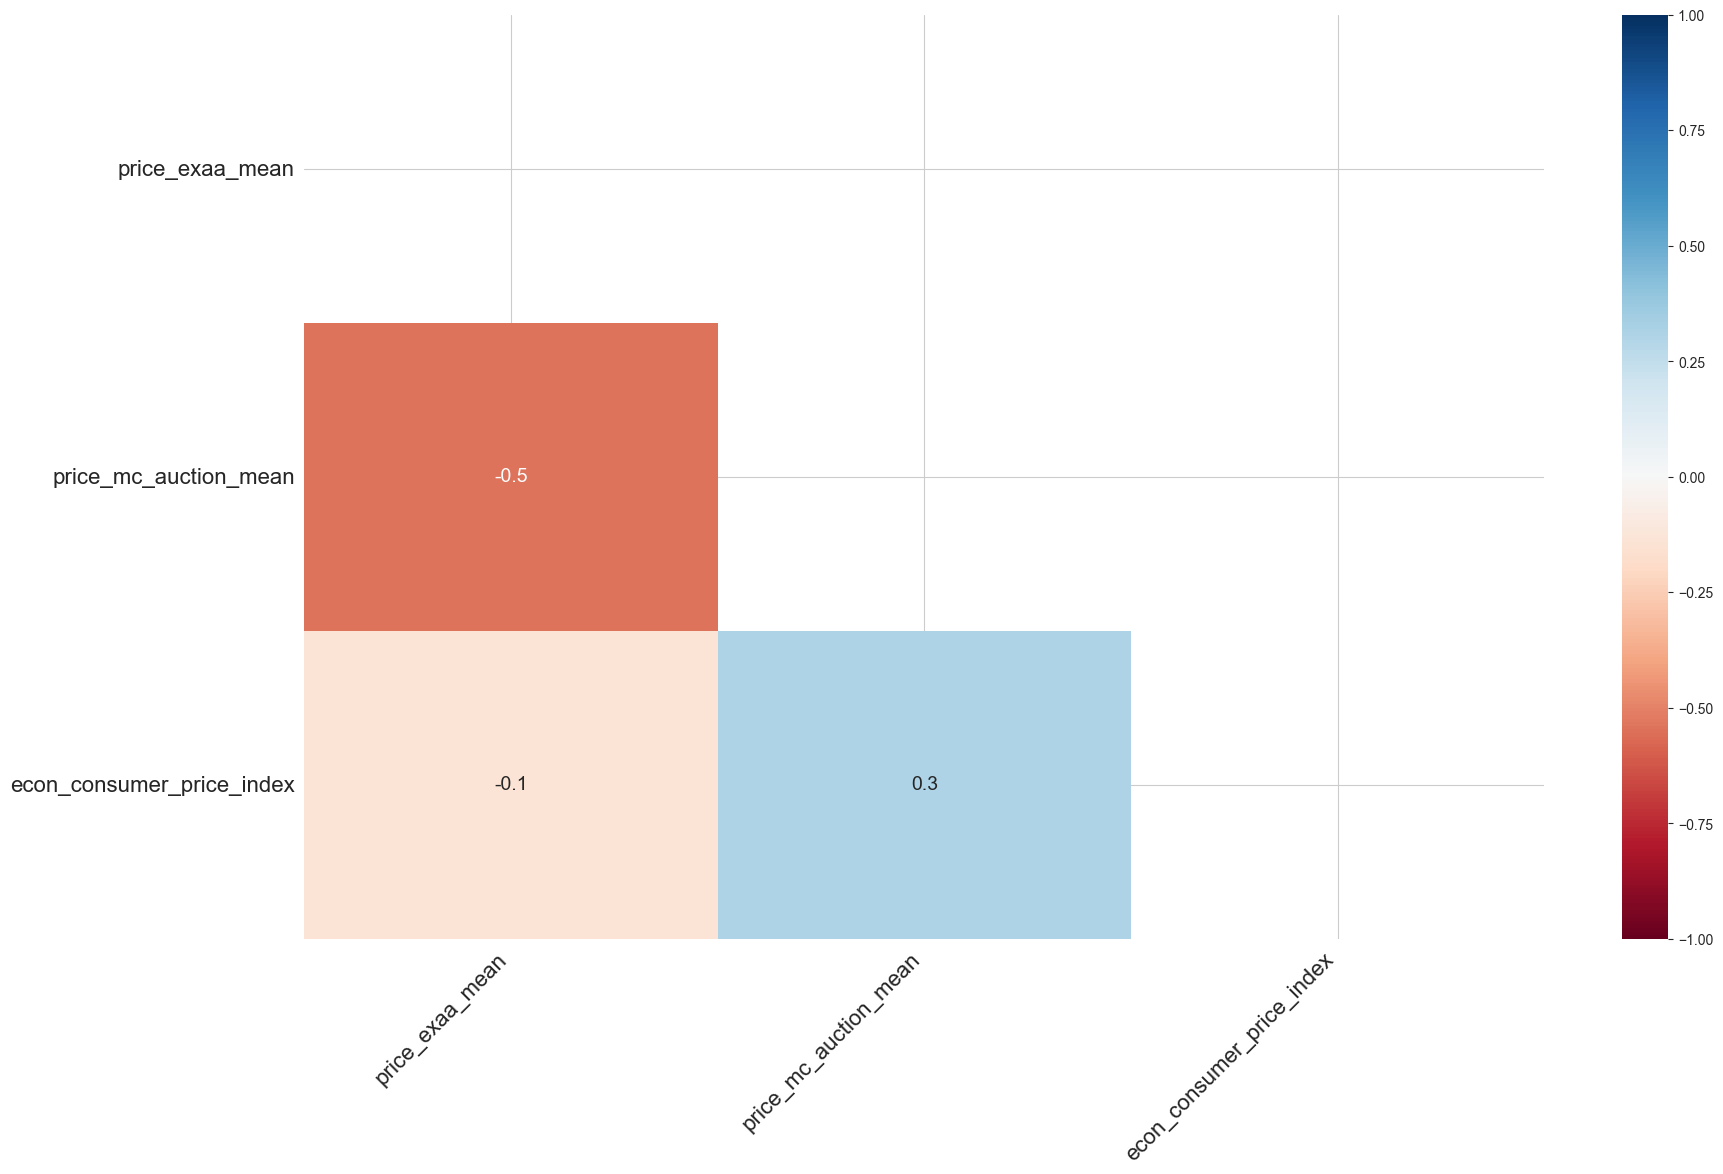

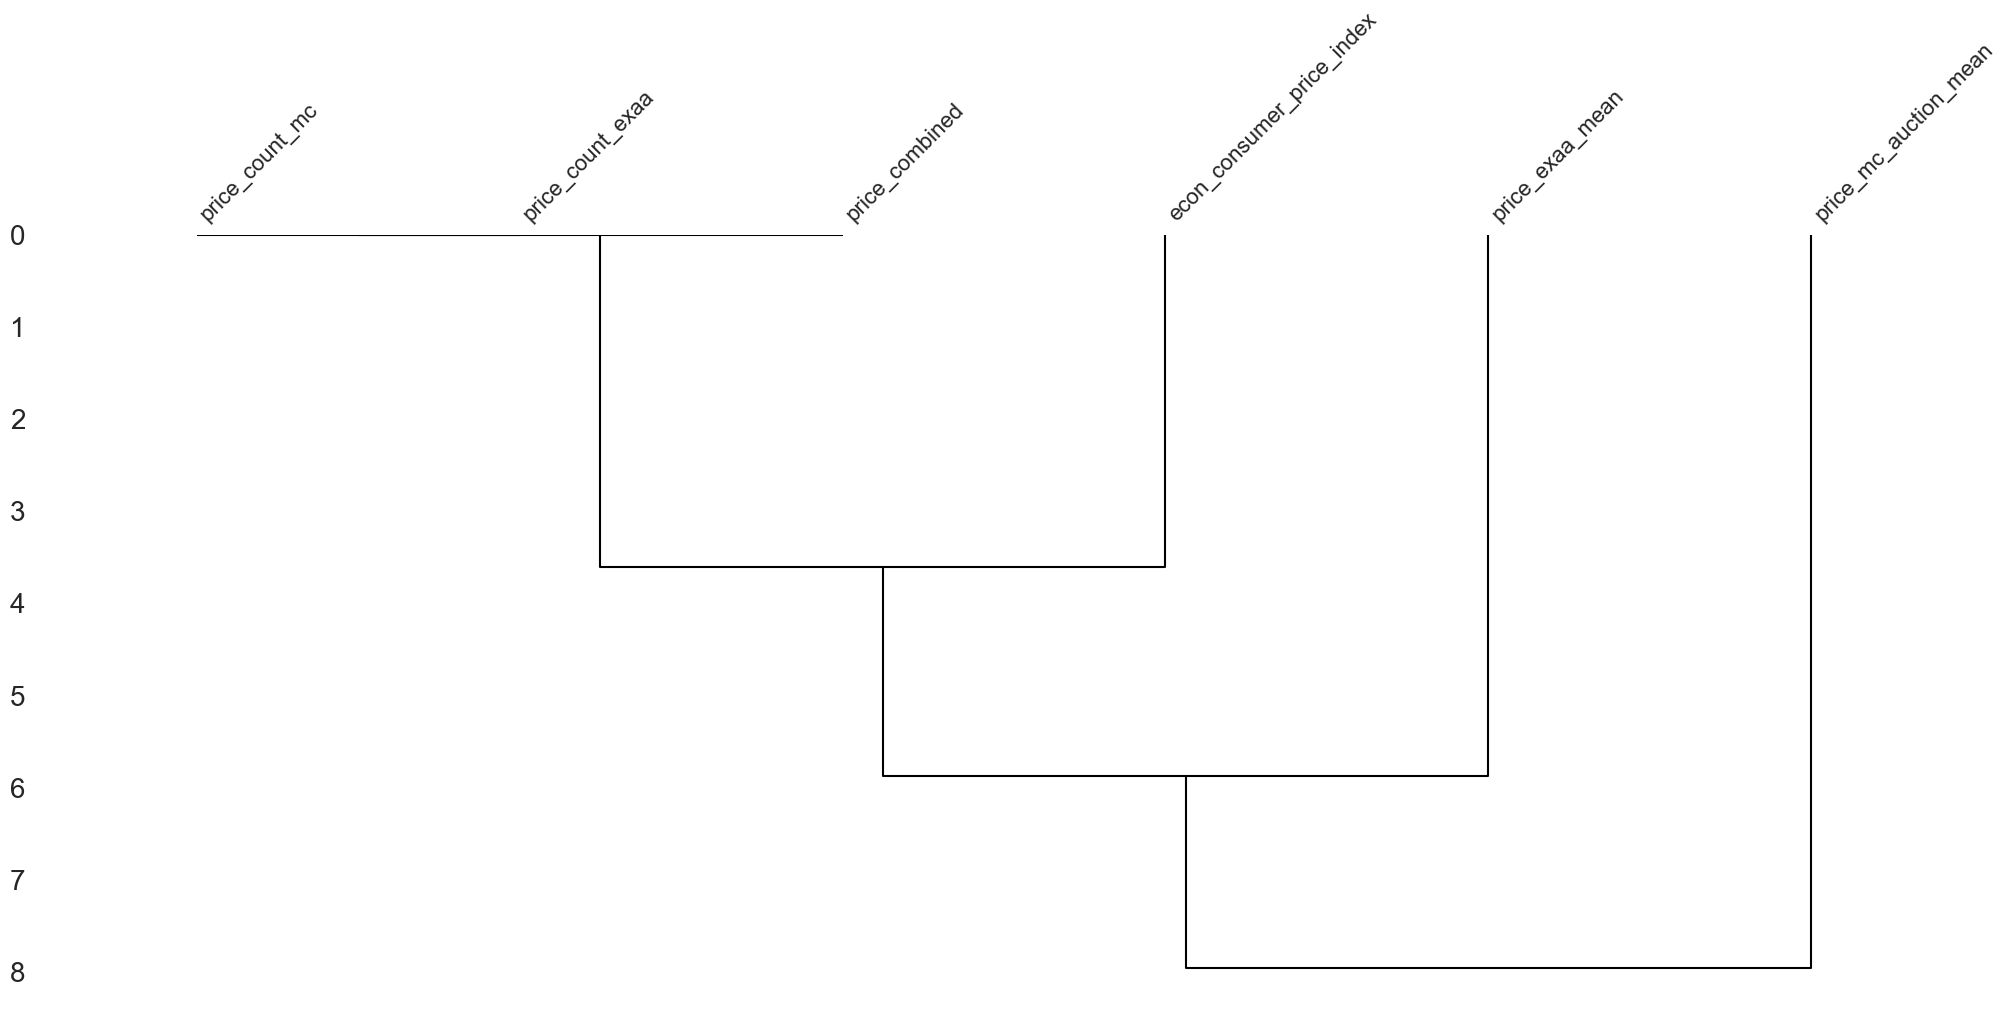

In [44]:
#electricity prices from exaa and mc auction only
msno.matrix(df_price, figsize=(7, 4))
msno.bar(df_price)
msno.heatmap(df_price)
msno.dendrogram(df_price)

# electricity prices have already been combined into price_combined
# price_combined is now the reference for the rest of the data

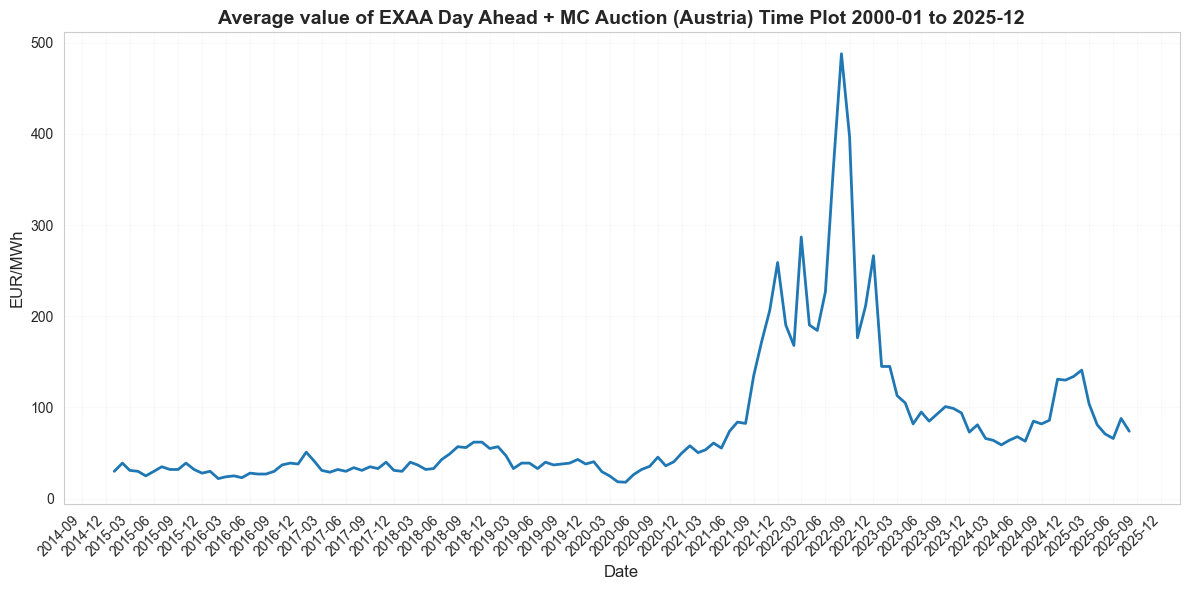

In [45]:
single_plot(df, 'price_combined', all, 'monthly', meta_lib_path)

<Axes: >

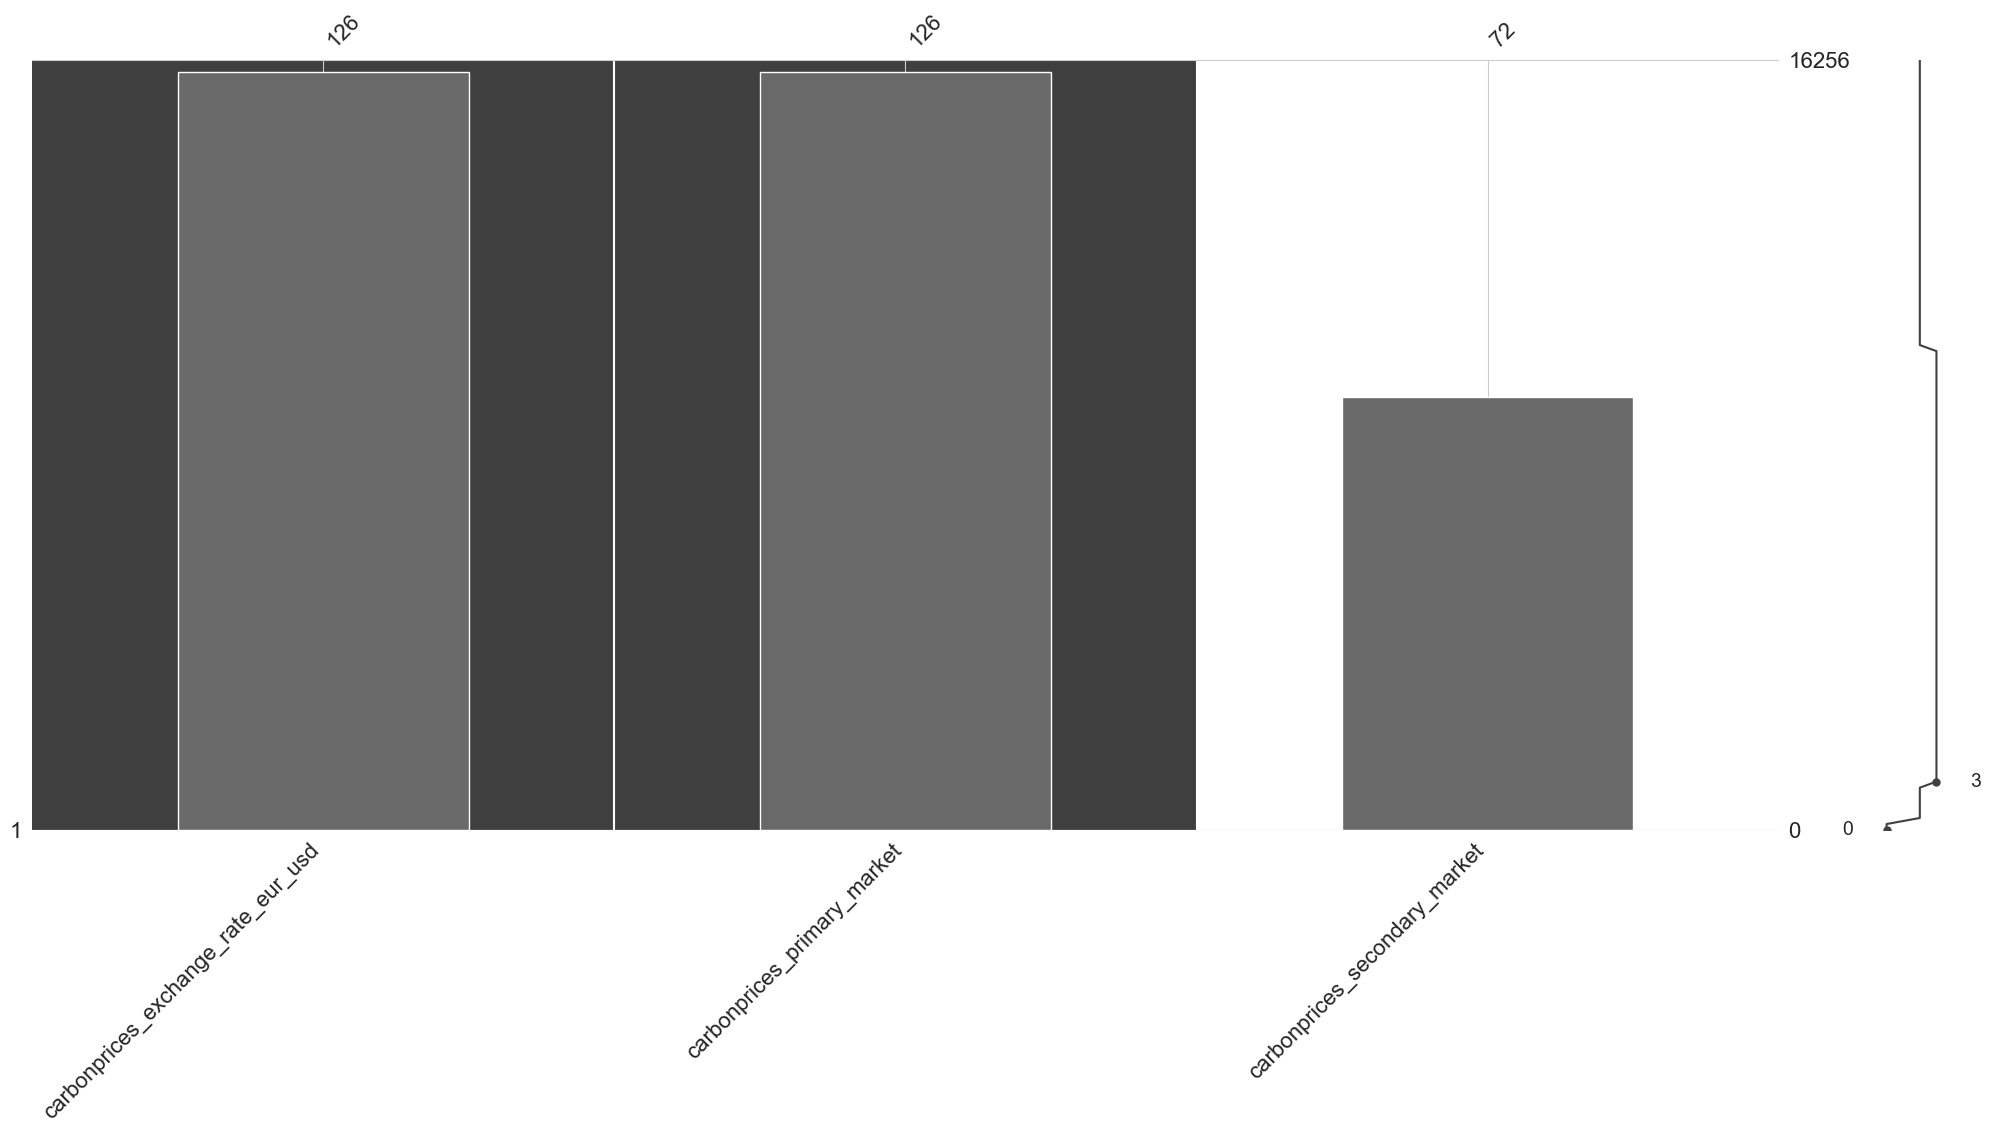

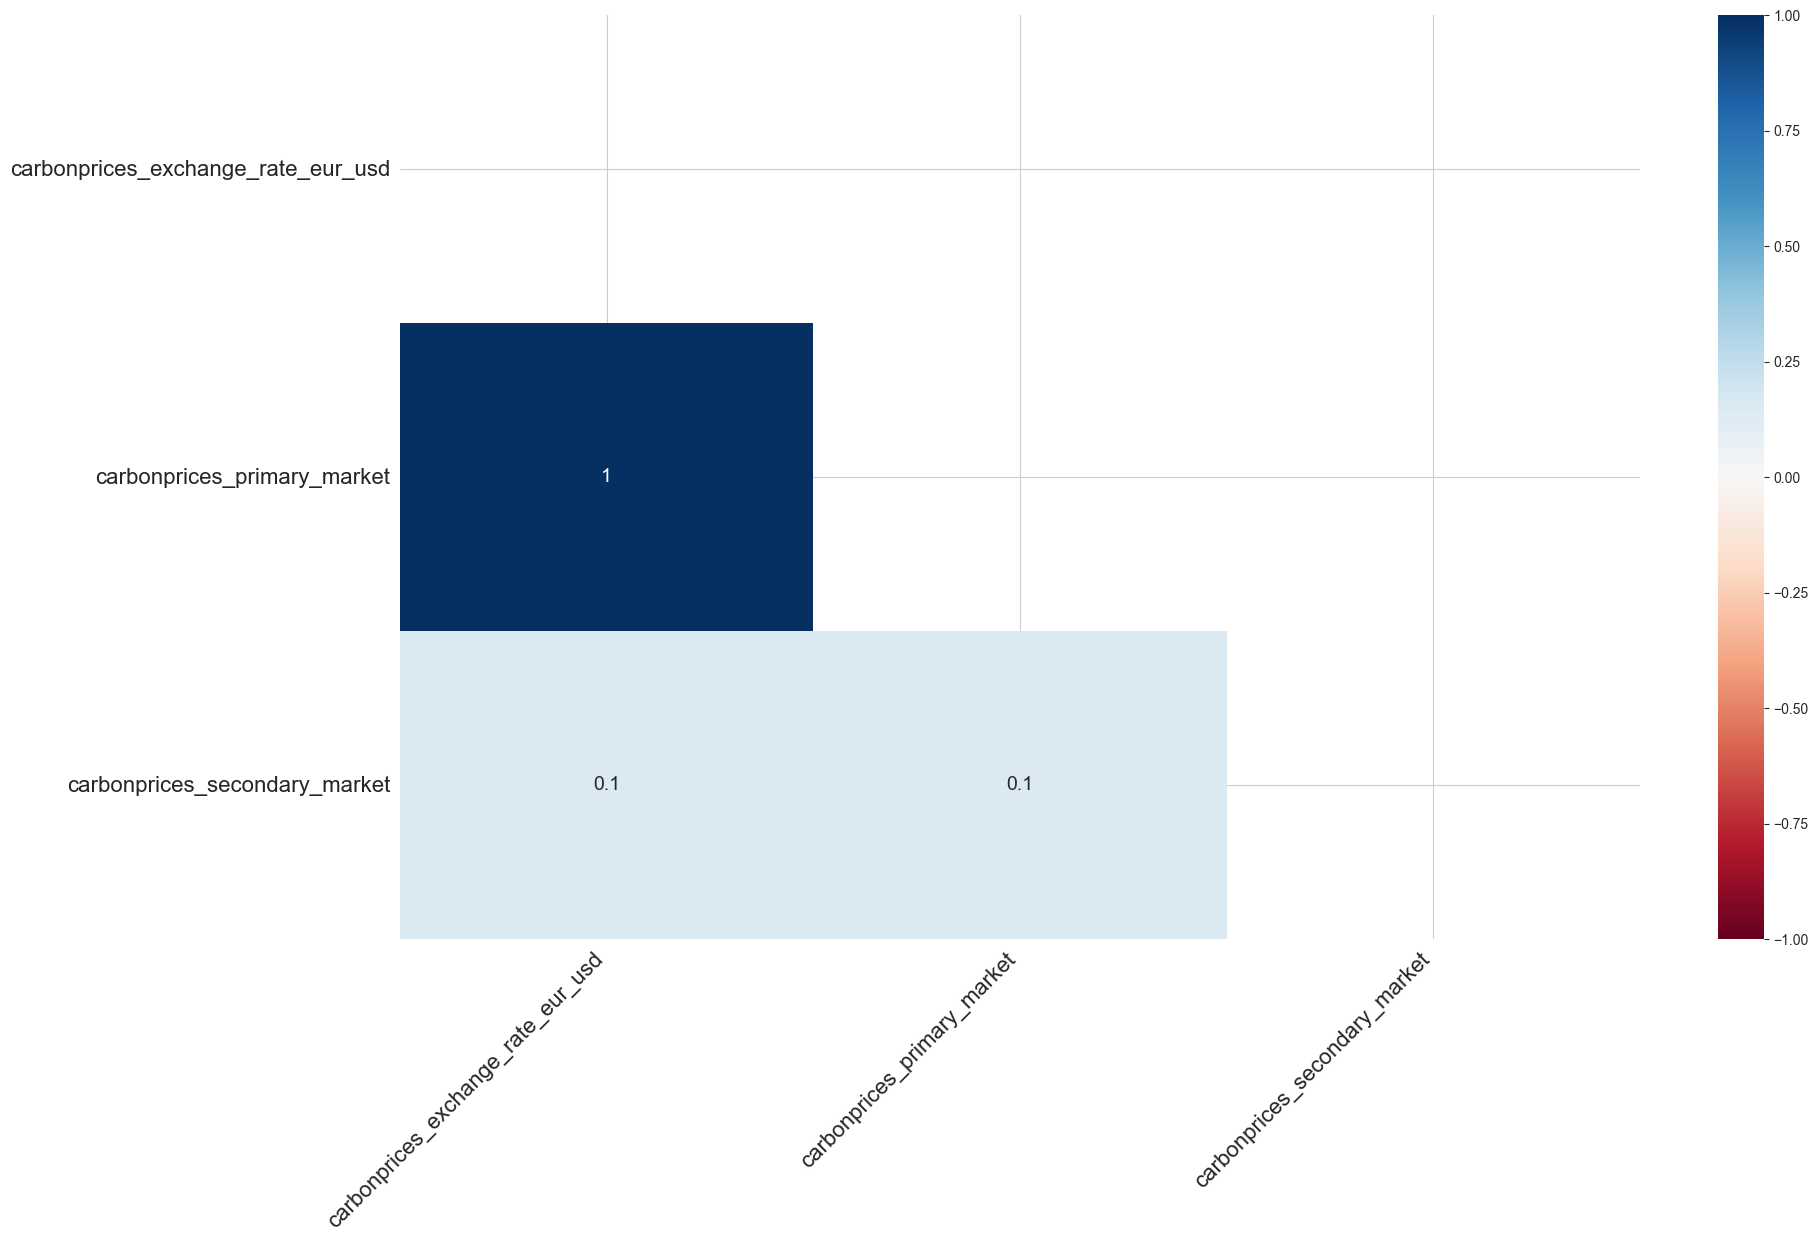

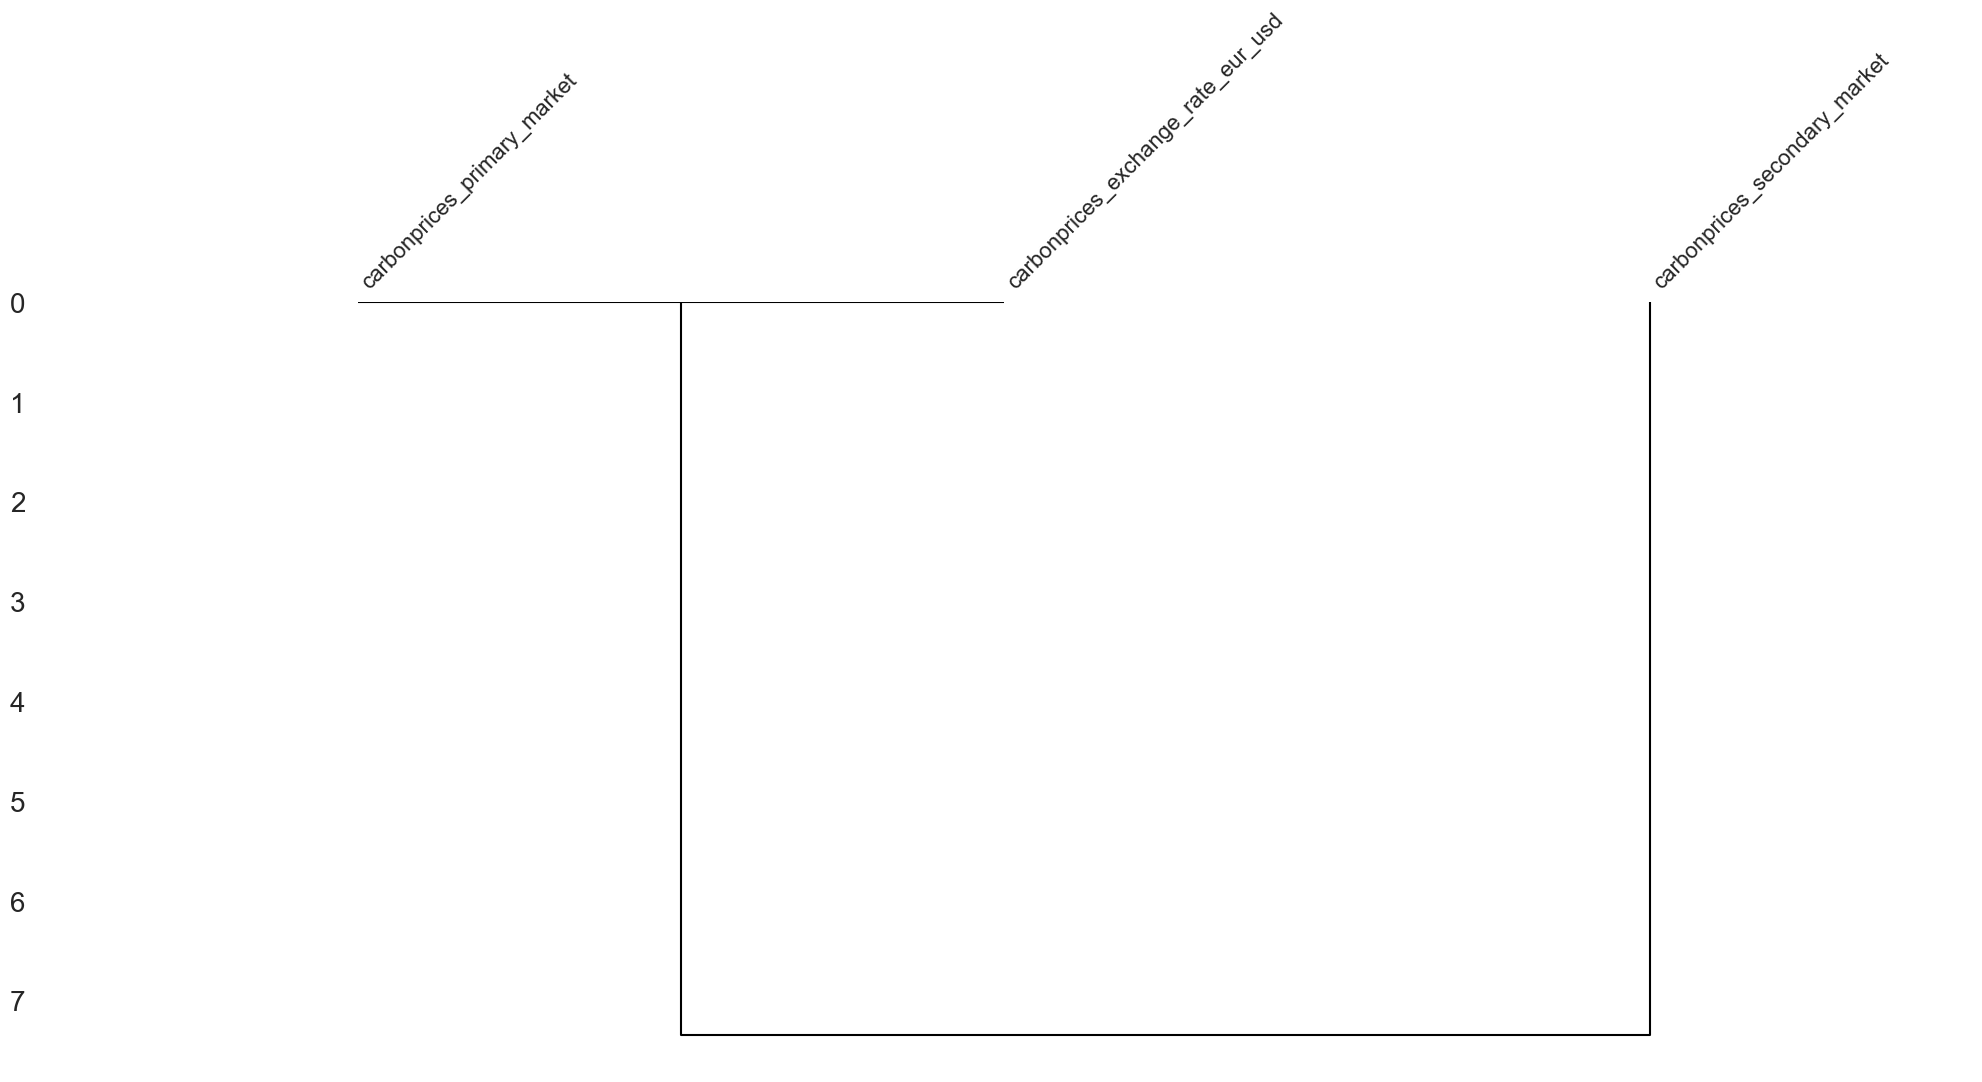

In [46]:
#carbon prices from icap only
msno.matrix(df_carbon, figsize=(7, 4))
msno.bar(df_carbon)
msno.heatmap(df_carbon)
msno.dendrogram(df_carbon)
#carbon prices for primary market are complete, but only 126 months available. 
#carbon prices for secondary market is available only until End of 2024

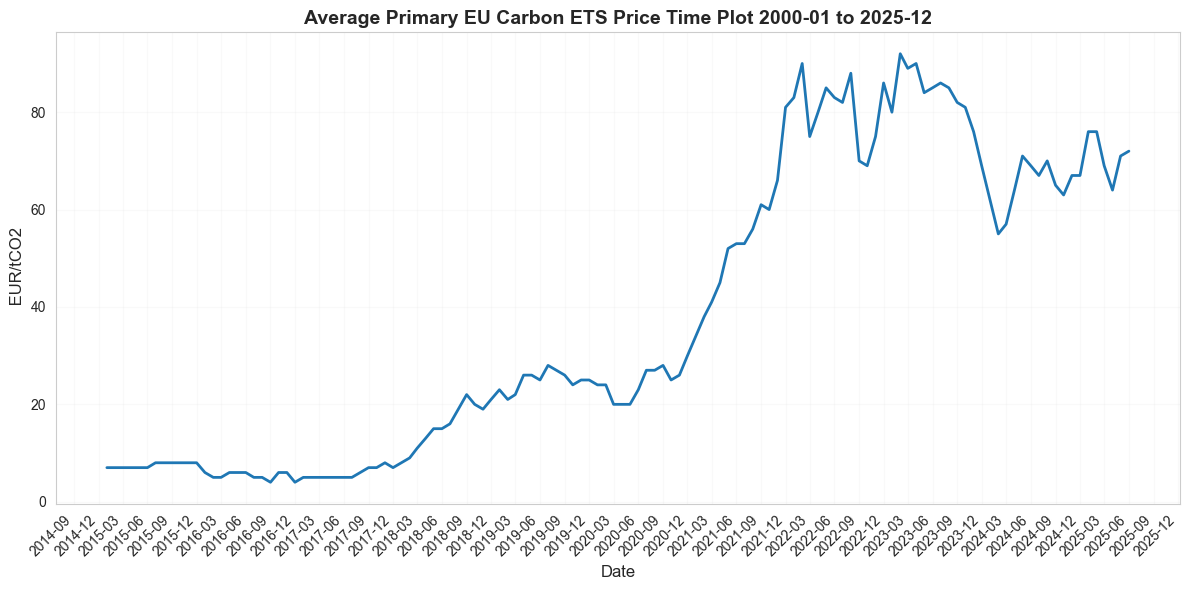

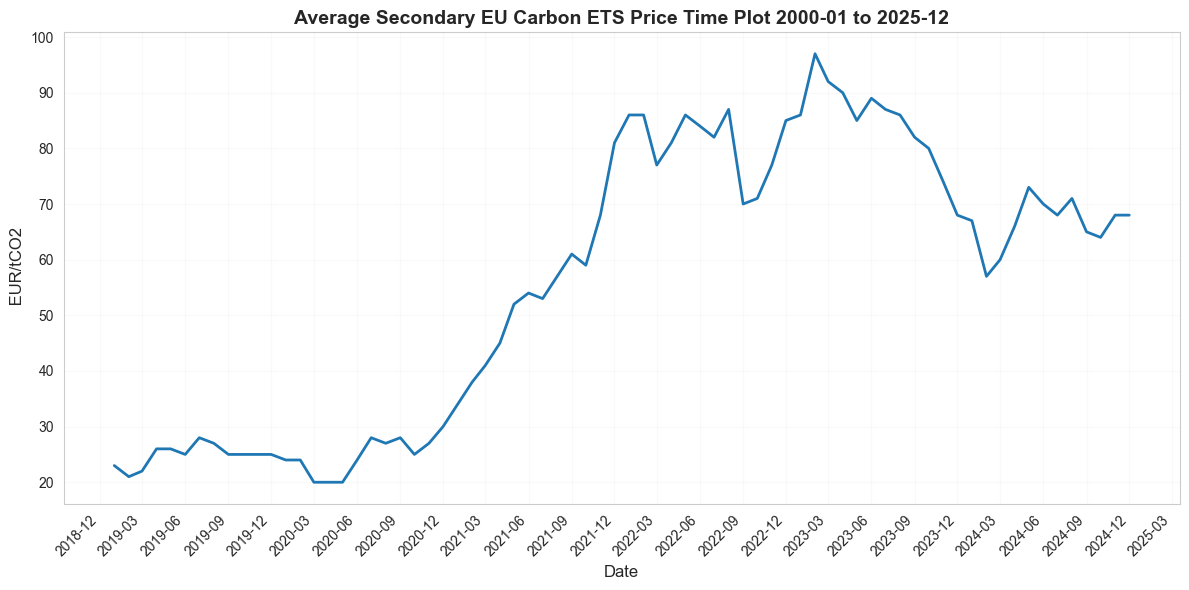

In [47]:
single_plot(df, 'carbonprices_primary_market', all, 'monthly', meta_lib_path)
single_plot(df, 'carbonprices_secondary_market', all, 'monthly', meta_lib_path)

c:\Users\paulr\Desktop\Capstone\capstone_env\Lib\site-packages\scipy\cluster\hierarchy.py:2950: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([dvw, 0])


<Axes: >

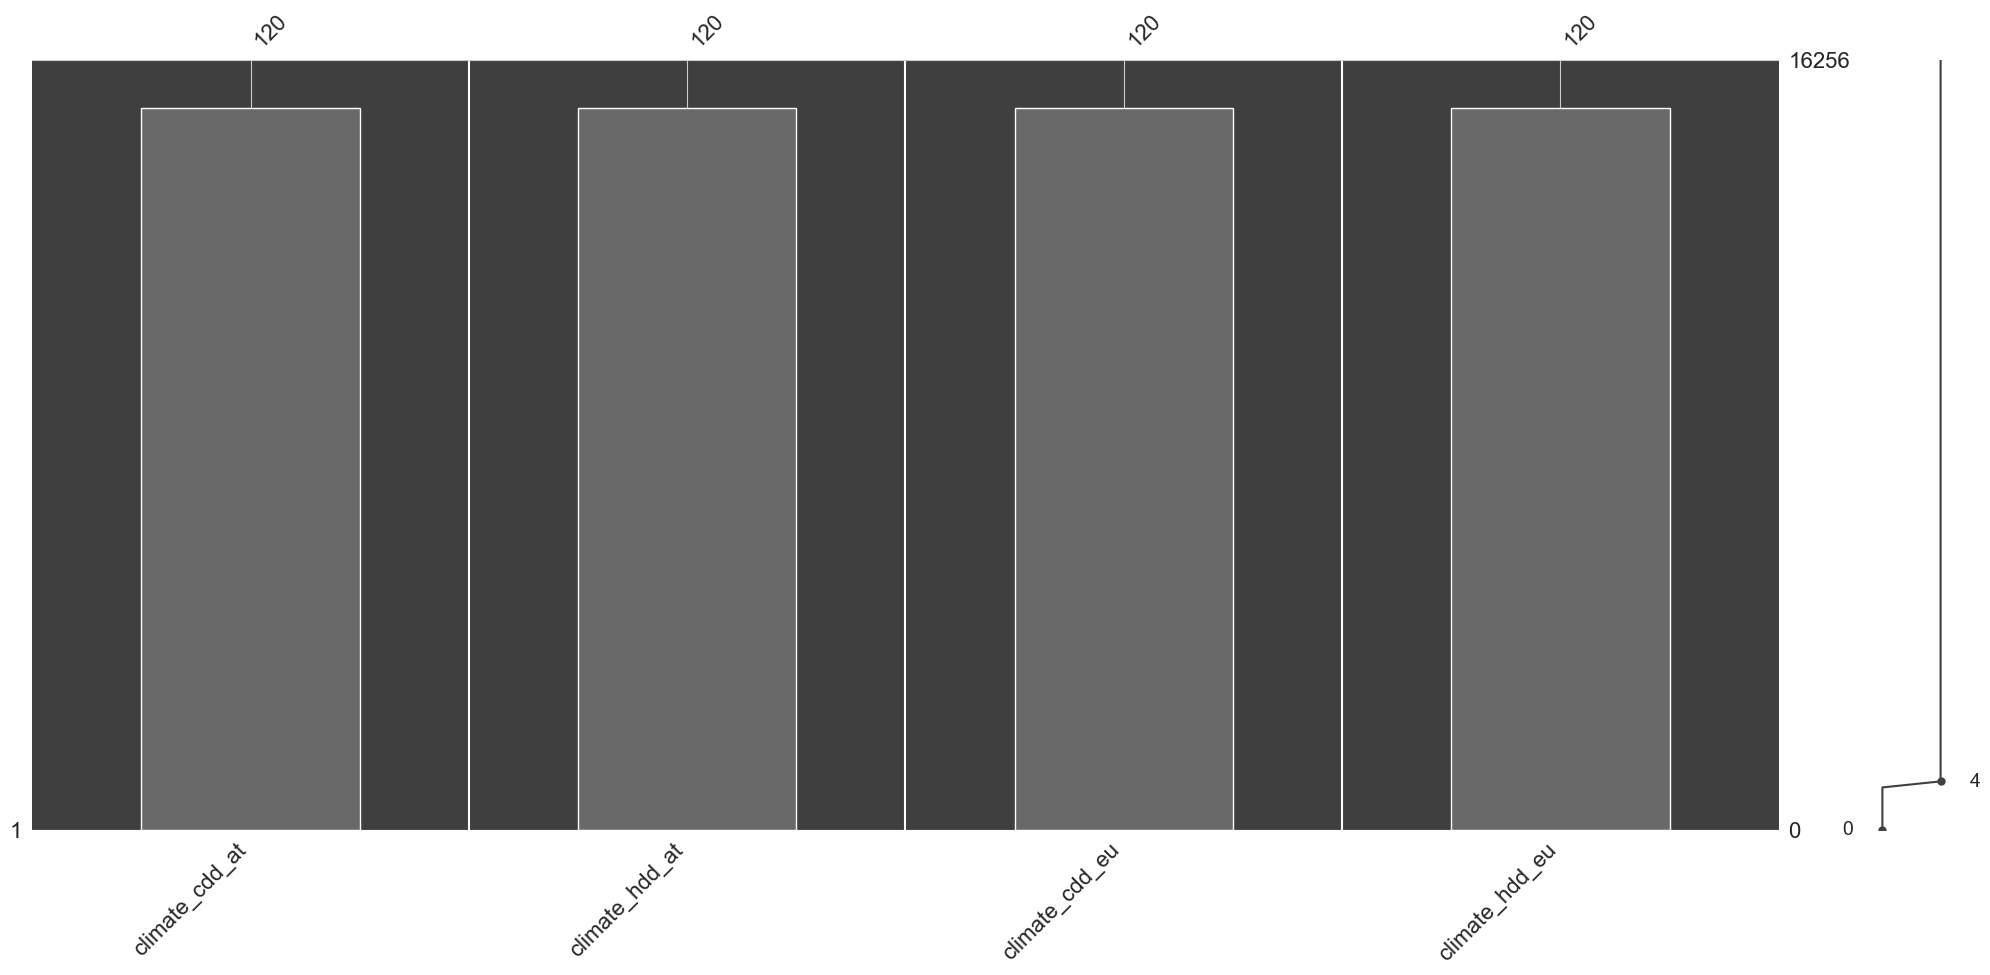

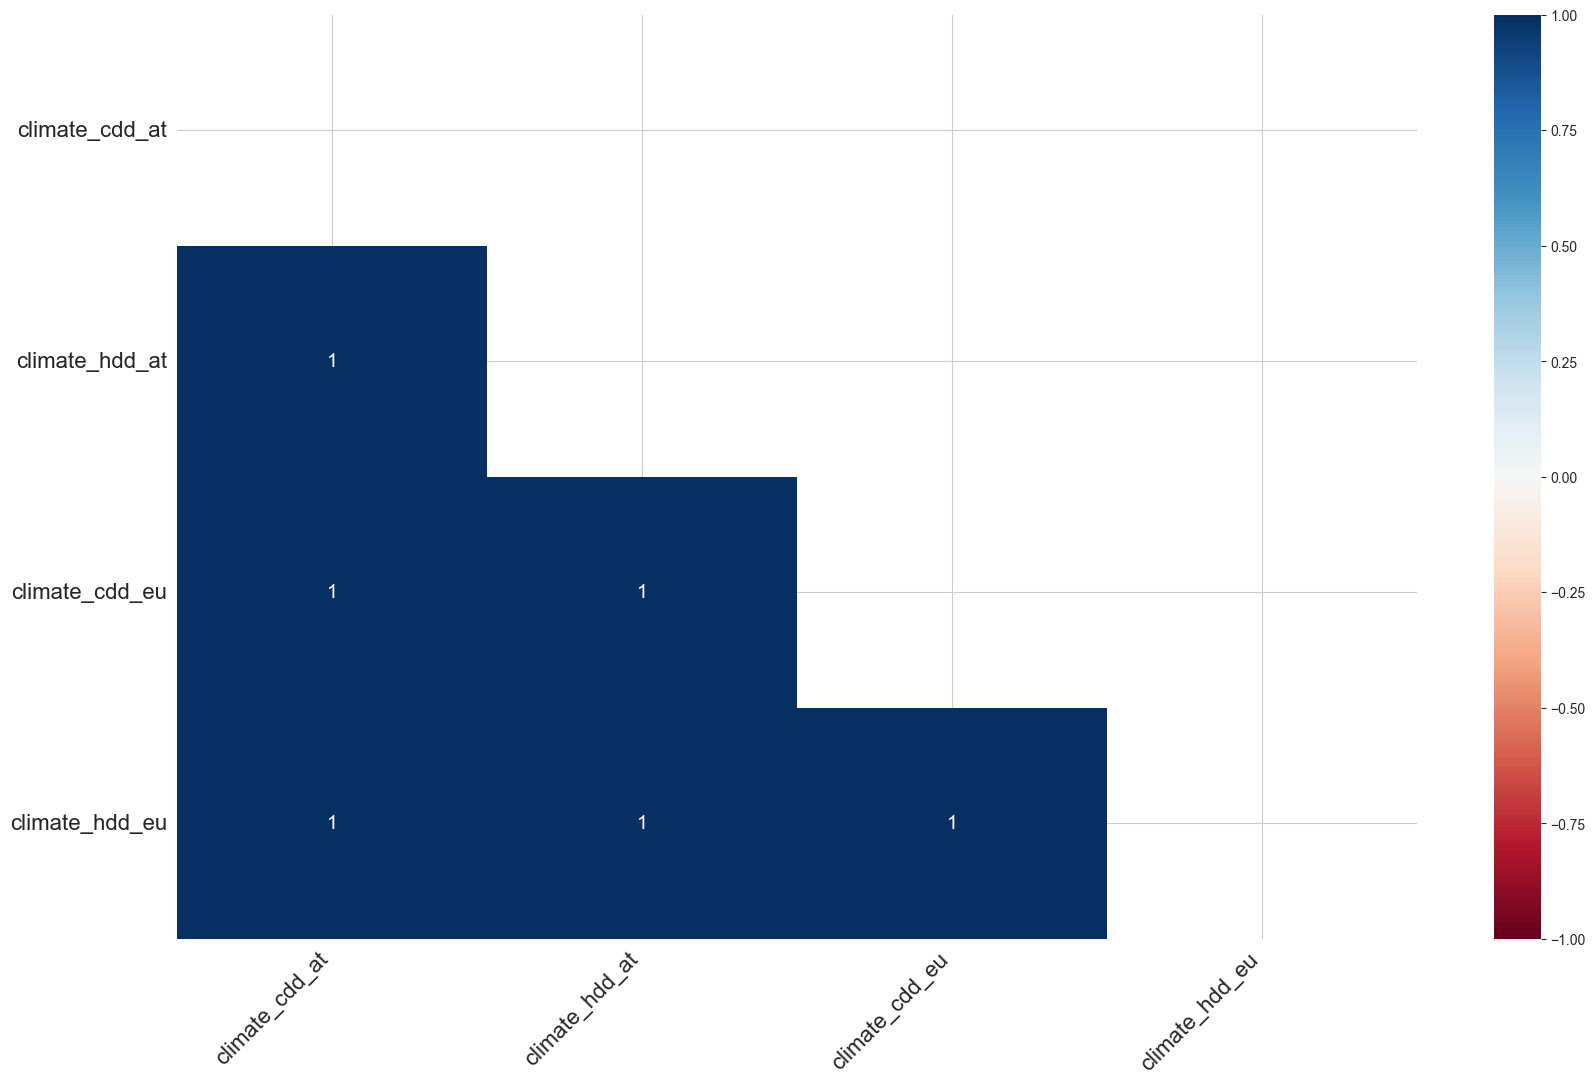

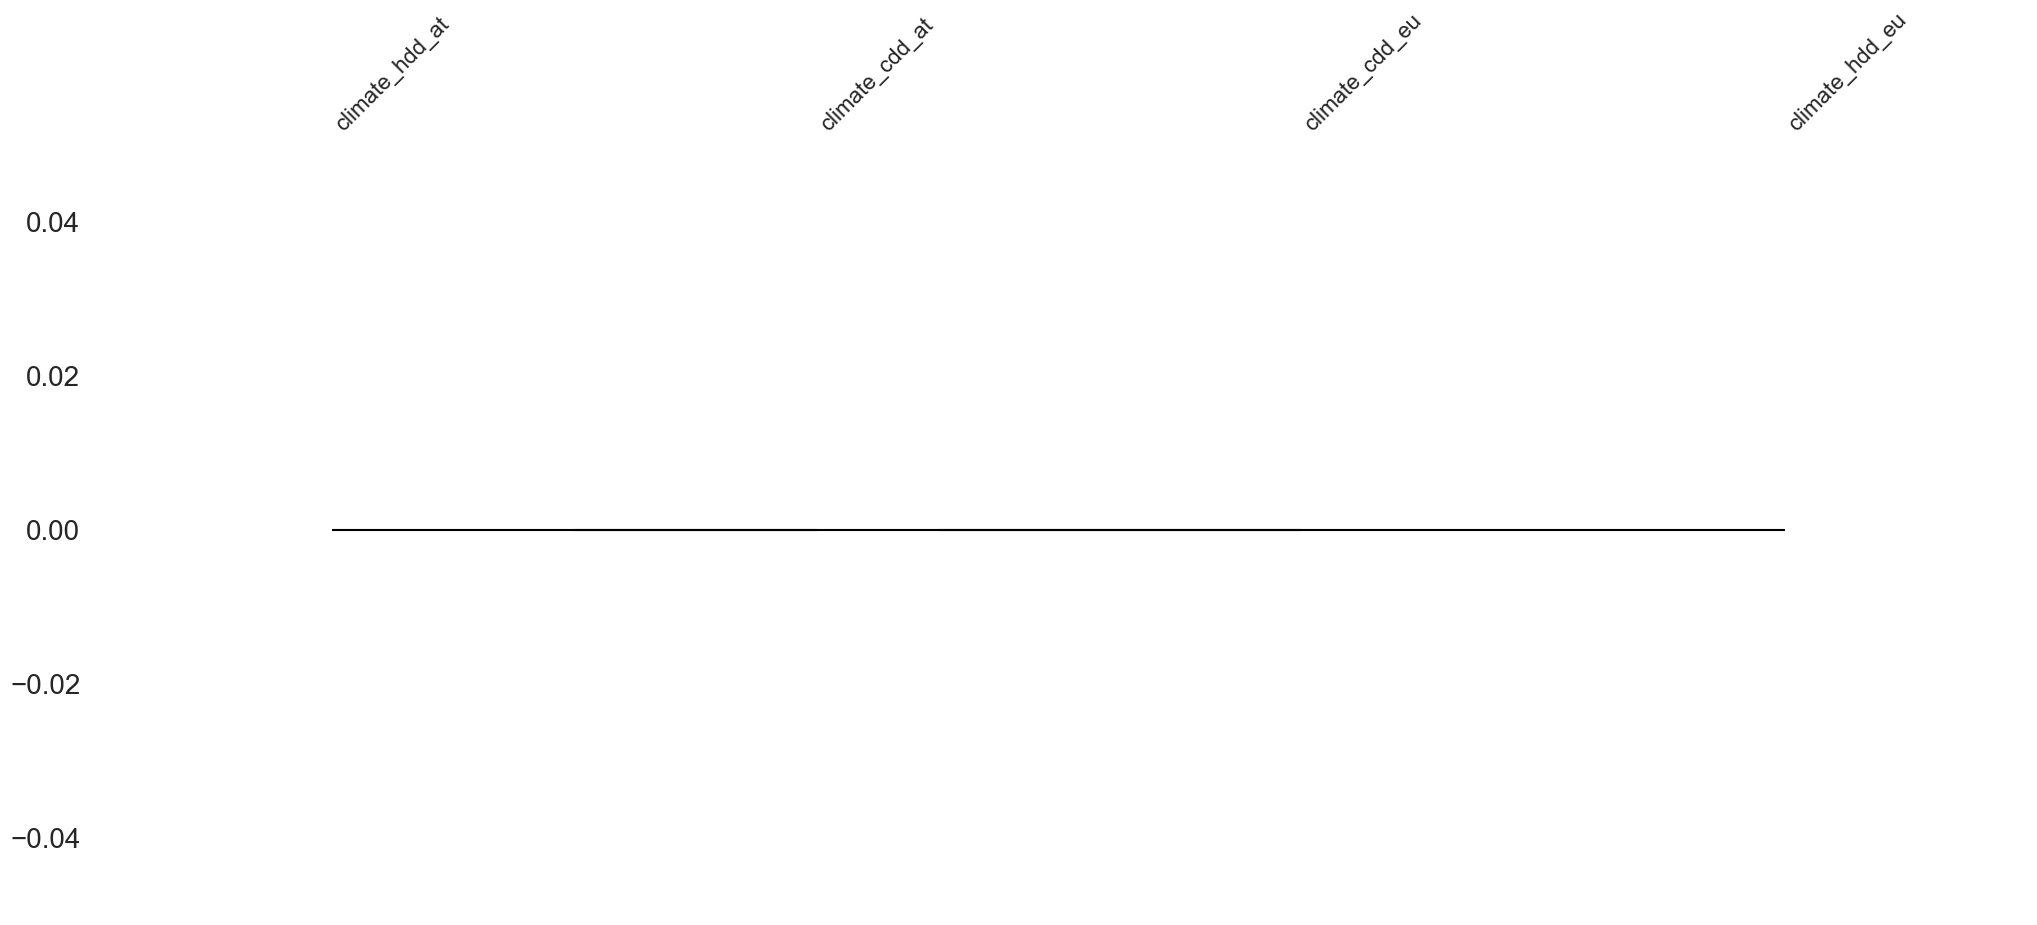

In [48]:
#climate data from EUROSTAT only
msno.matrix(df_climate, figsize=(7, 4))
msno.bar(df_climate)
msno.heatmap(df_climate)
msno.dendrogram(df_climate)

# climate data is complete, but only available for 120 months, until End of 2024. 
# this is due to late reporting (no 2025 data yet)

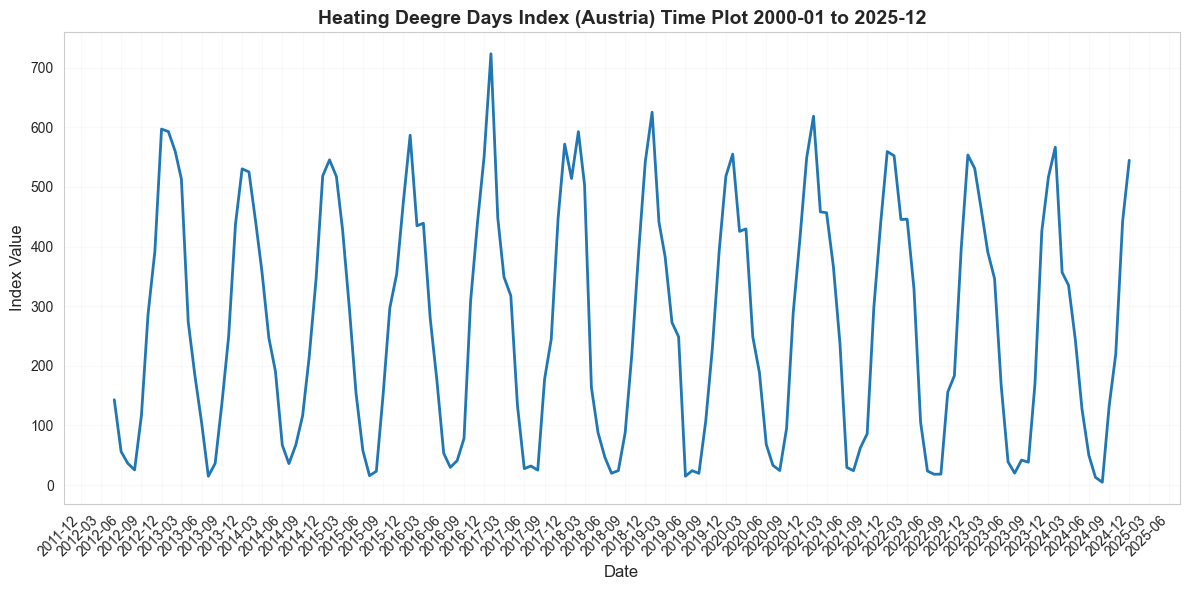

In [49]:
single_plot(df, 'climate_hdd_at', all, 'monthly', meta_lib_path)

<Axes: >

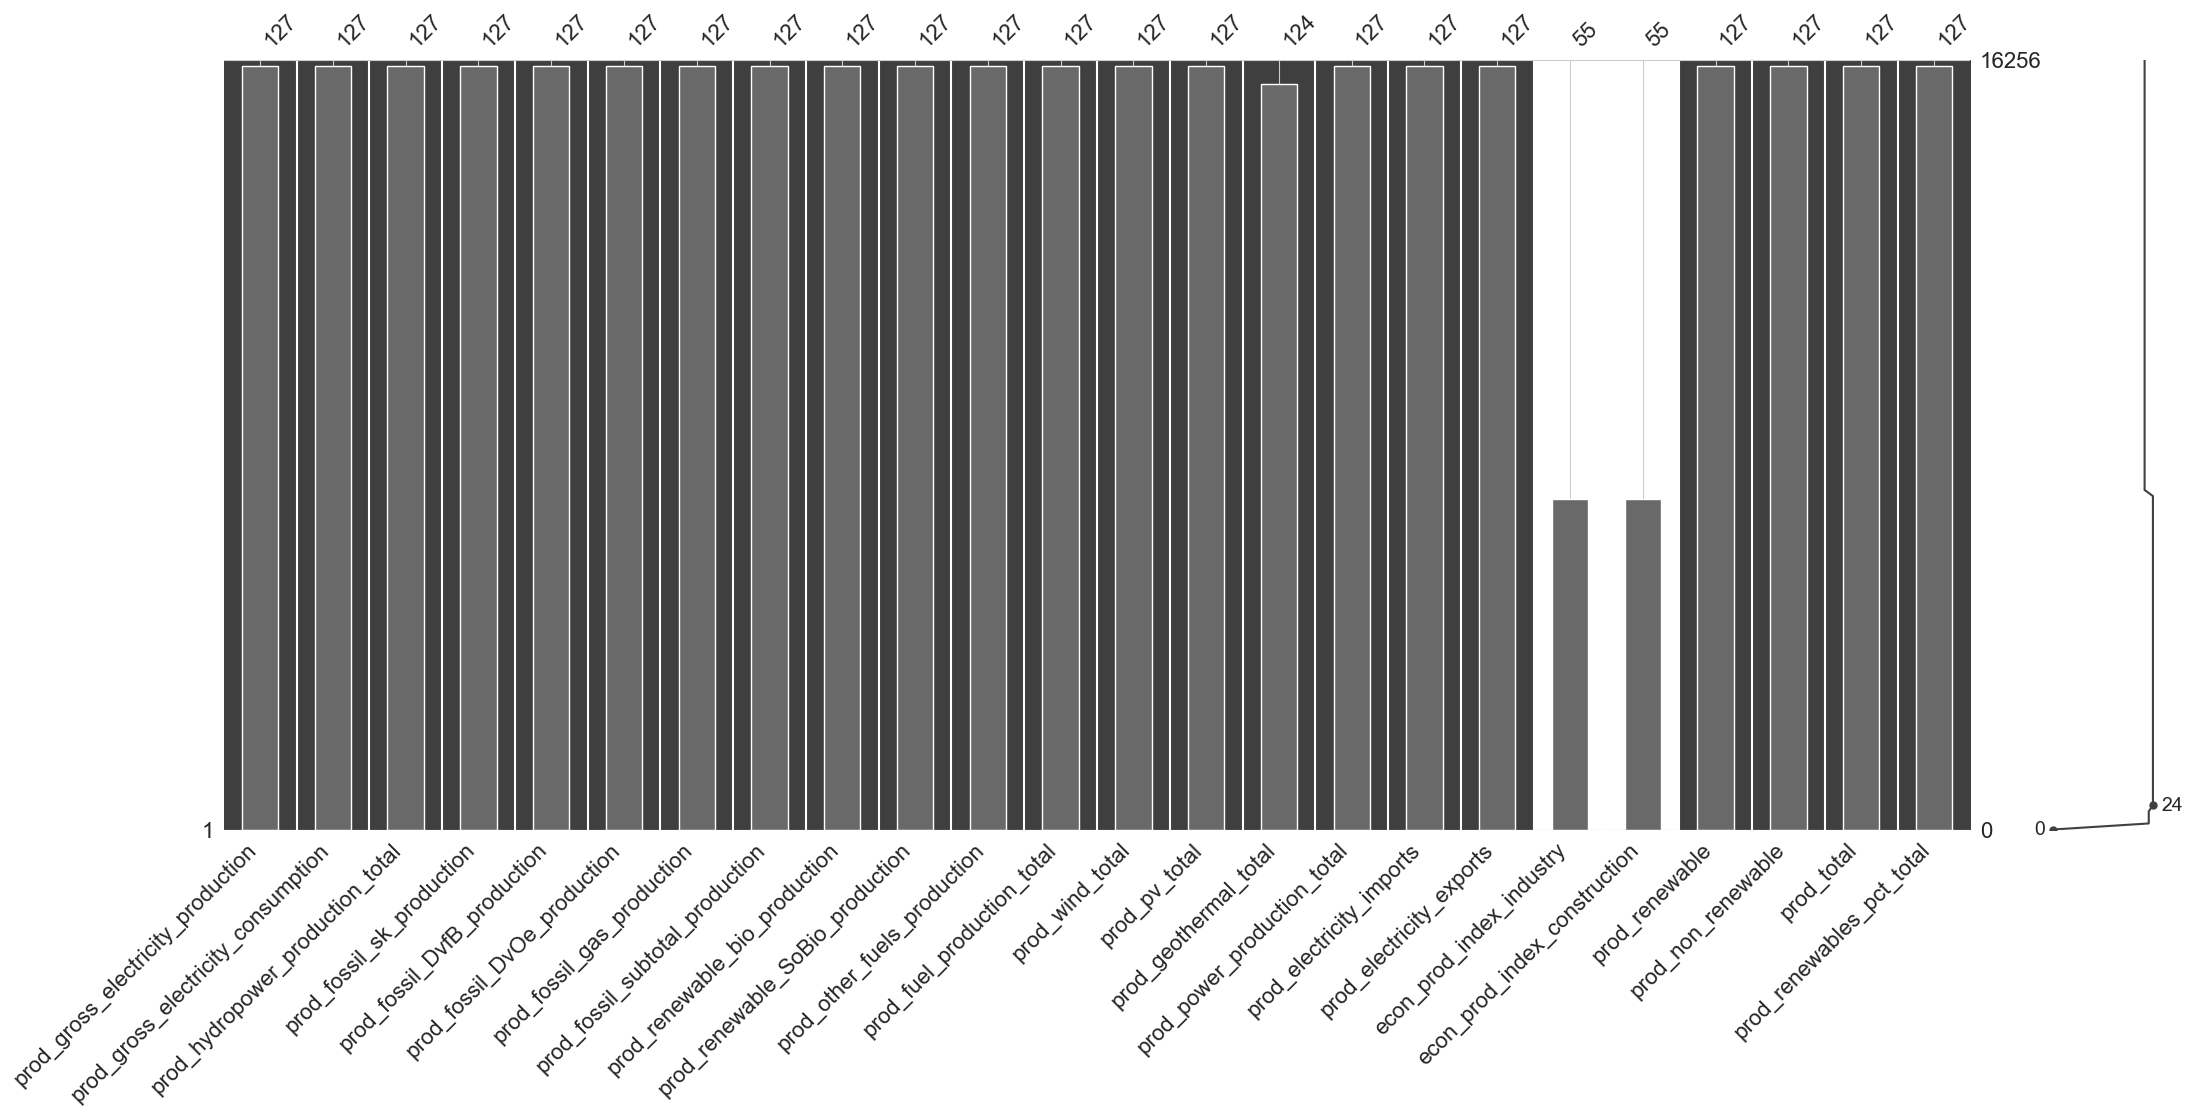

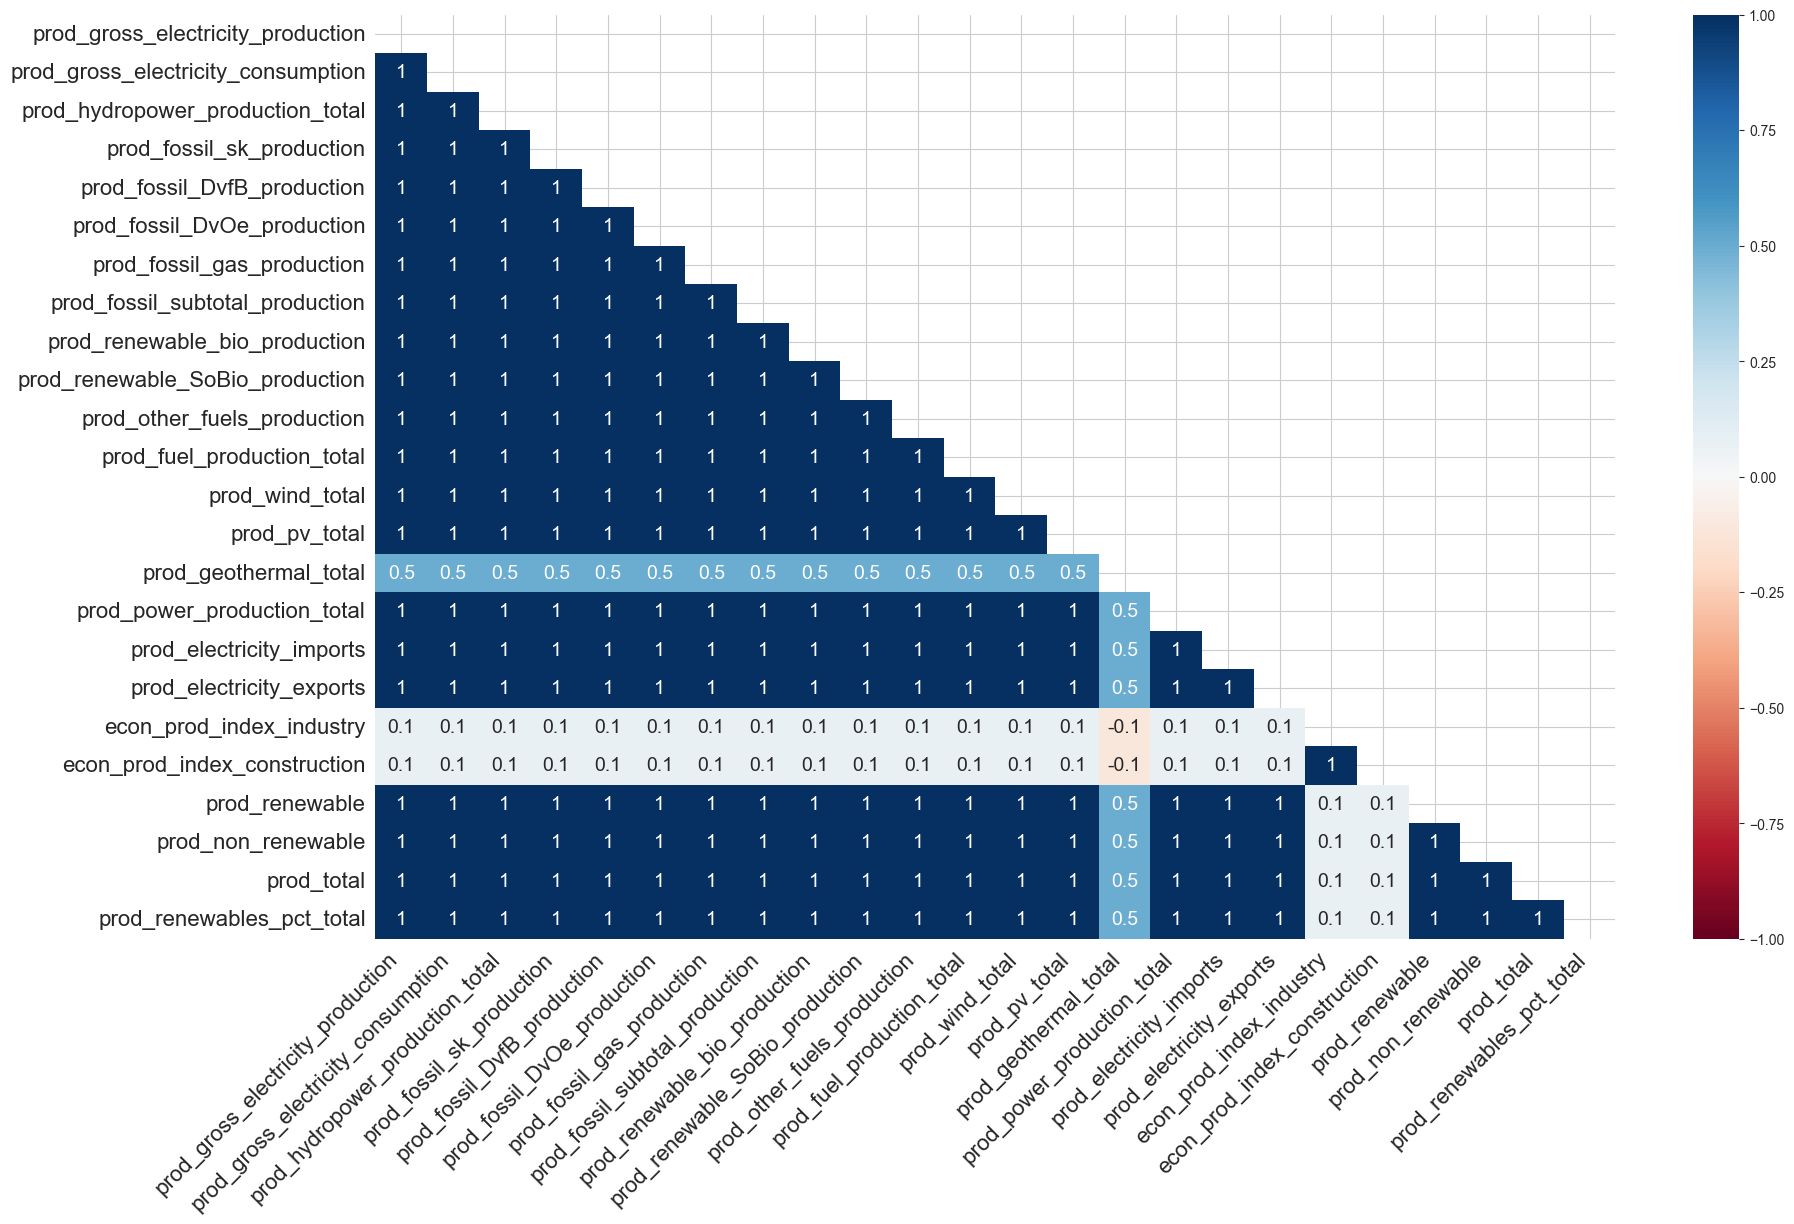

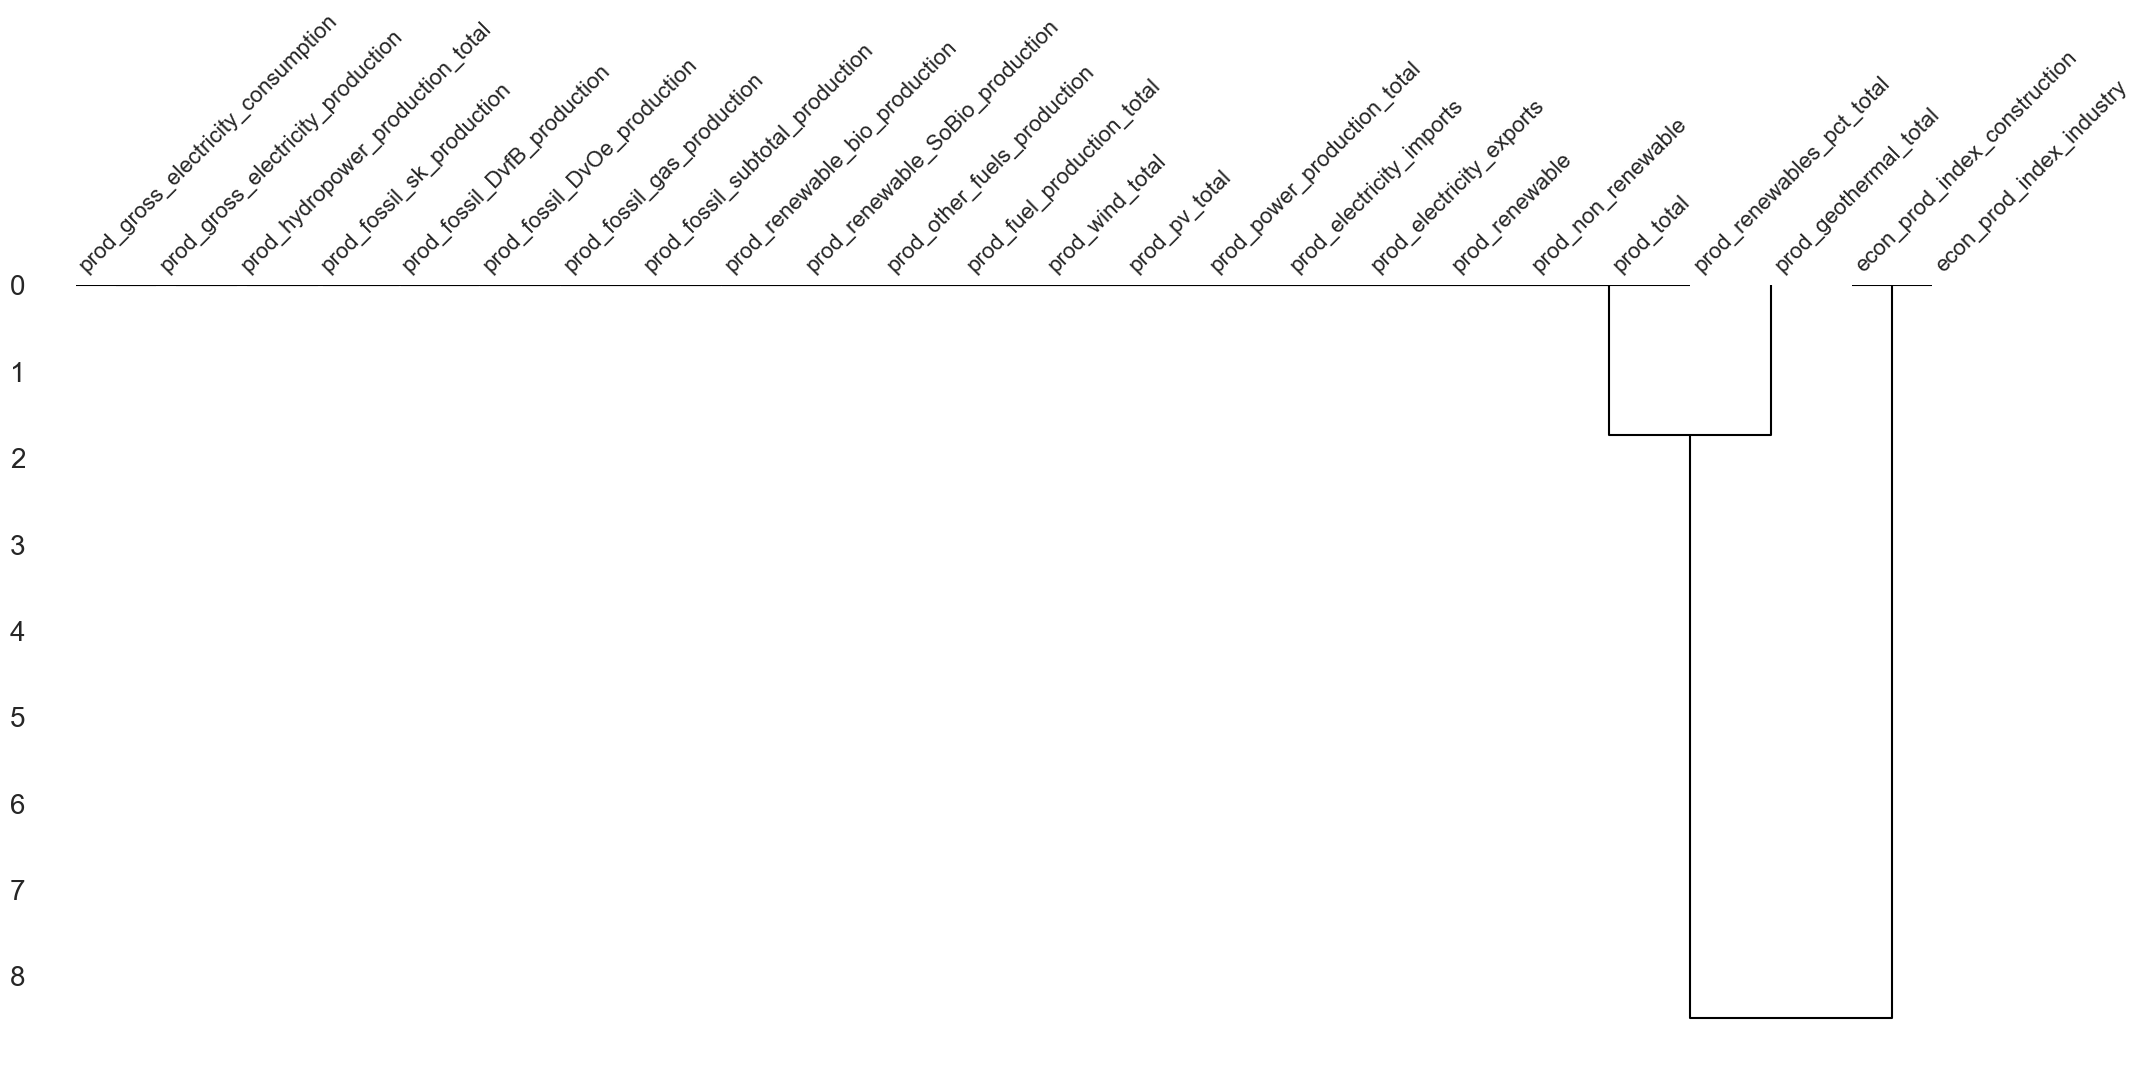

In [50]:
#electricity production data from E-Control only
msno.matrix(df_prod, figsize=(7, 4))
msno.bar(df_prod)
msno.heatmap(df_prod)
msno.dendrogram(df_prod)

# econ_prod_index_industry and econ_prod_index_construction are mixed int the electricity production data
# this is due to the filtering method used (filter like 'prod_')

# electricity production data is mostly complete, 1 month less than price_combined. probably due to reporting delays
# geothermal power is missing for several months, apparently lagging behind other production data
# it is also mostly zero. it will therefore be dropped in the modeling phase

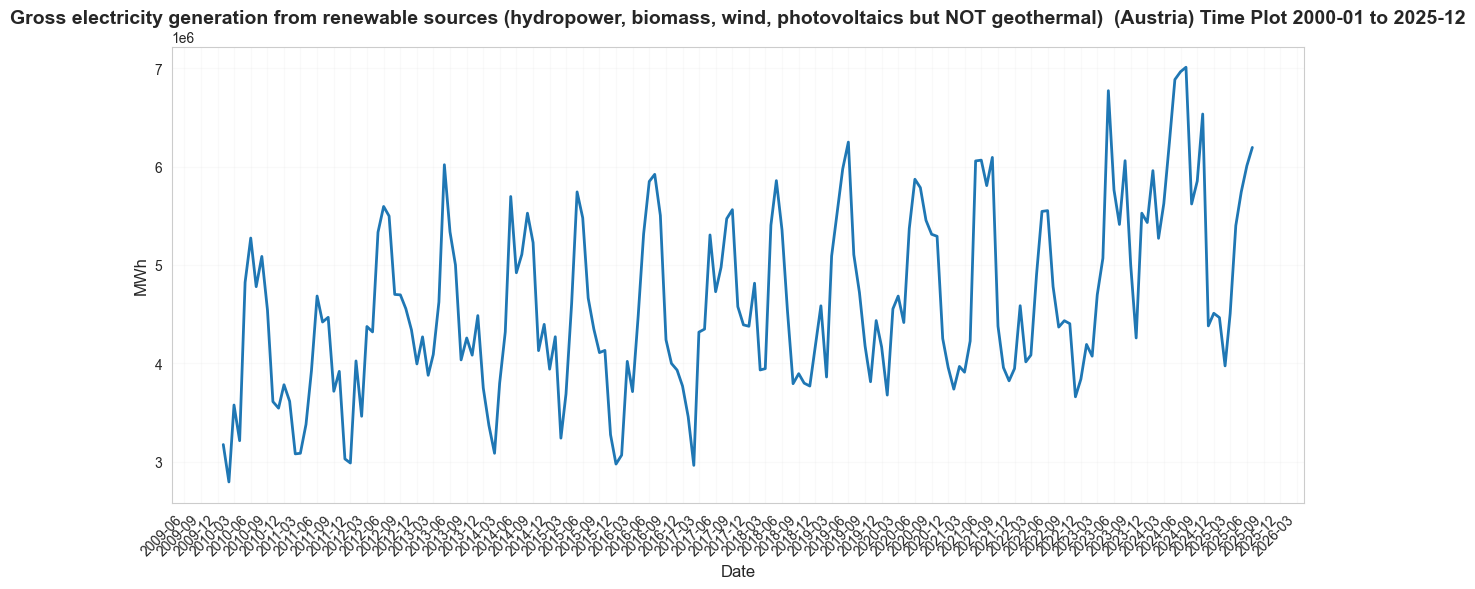

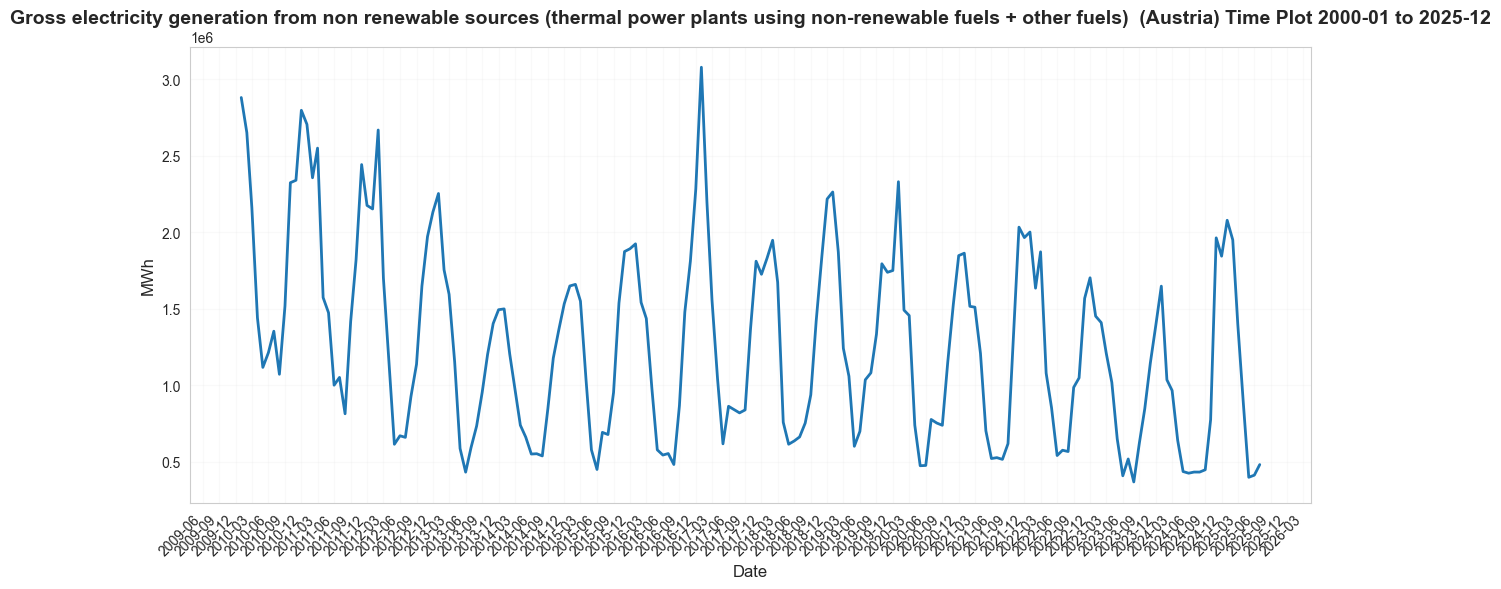

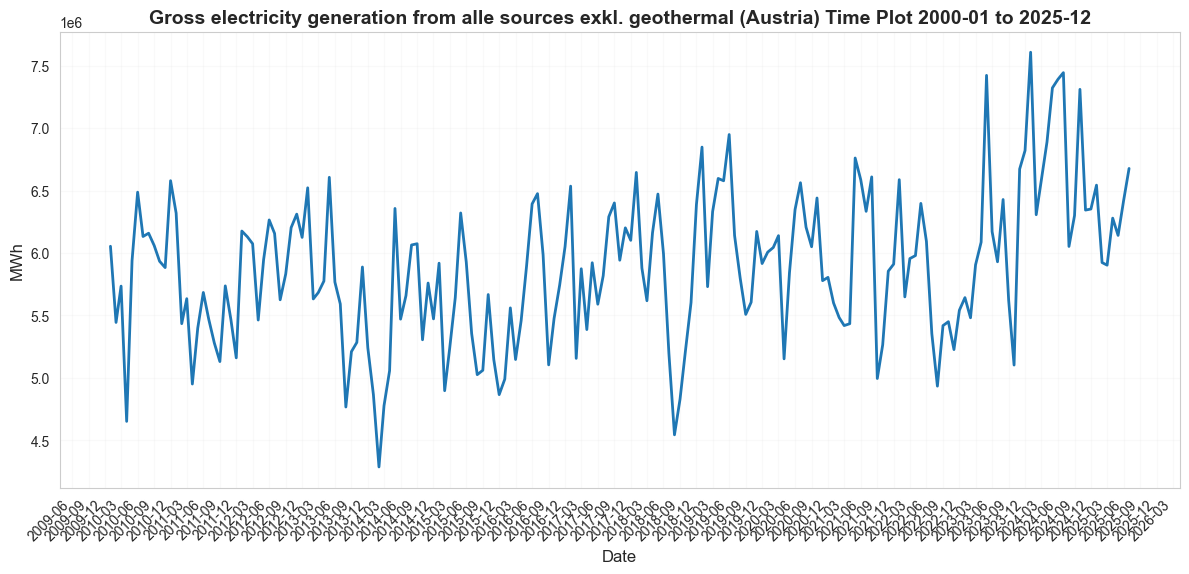

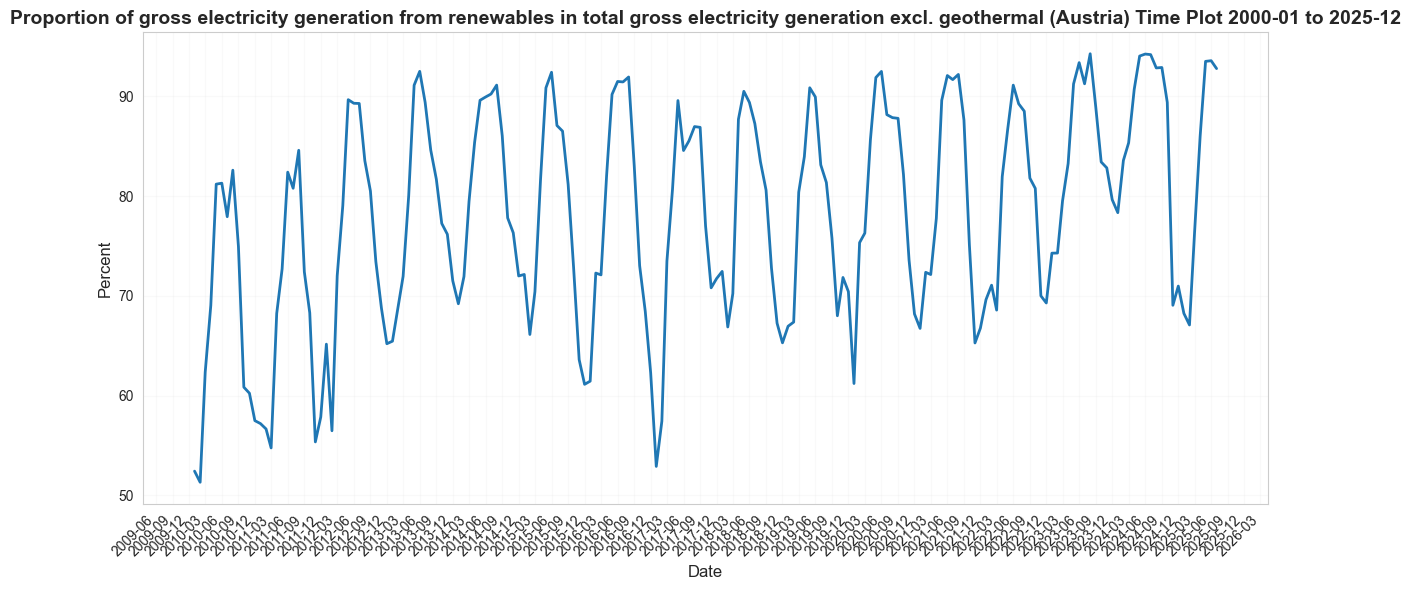

In [59]:
single_plot(df, 'prod_renewable', all, 'monthly', meta_lib_path)
single_plot(df, 'prod_non_renewable', all, 'monthly', meta_lib_path)
single_plot(df, 'prod_total', all, 'monthly', meta_lib_path)
single_plot(df, 'prod_renewables_pct_total', all, 'monthly', meta_lib_path)

<Axes: >

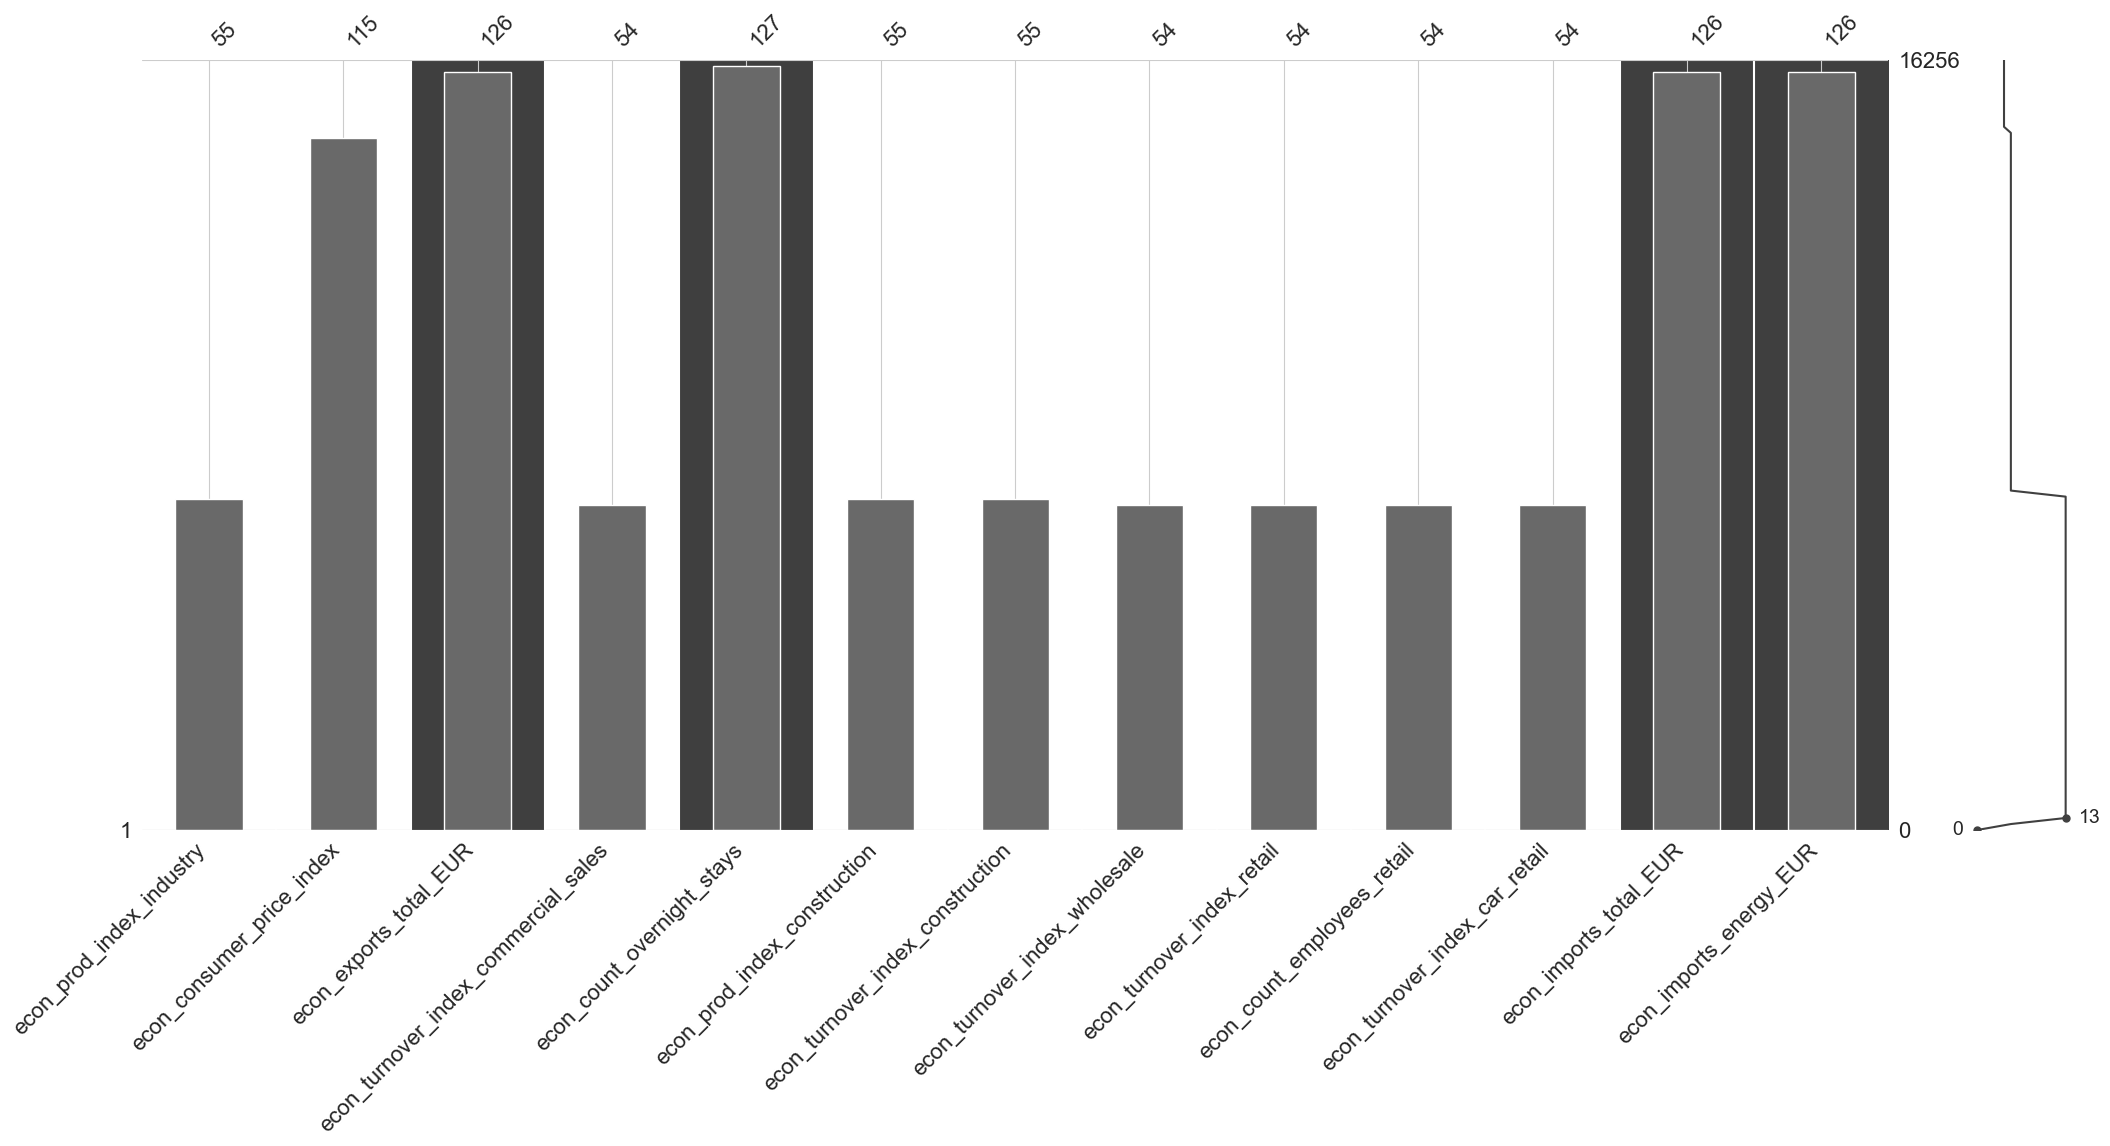

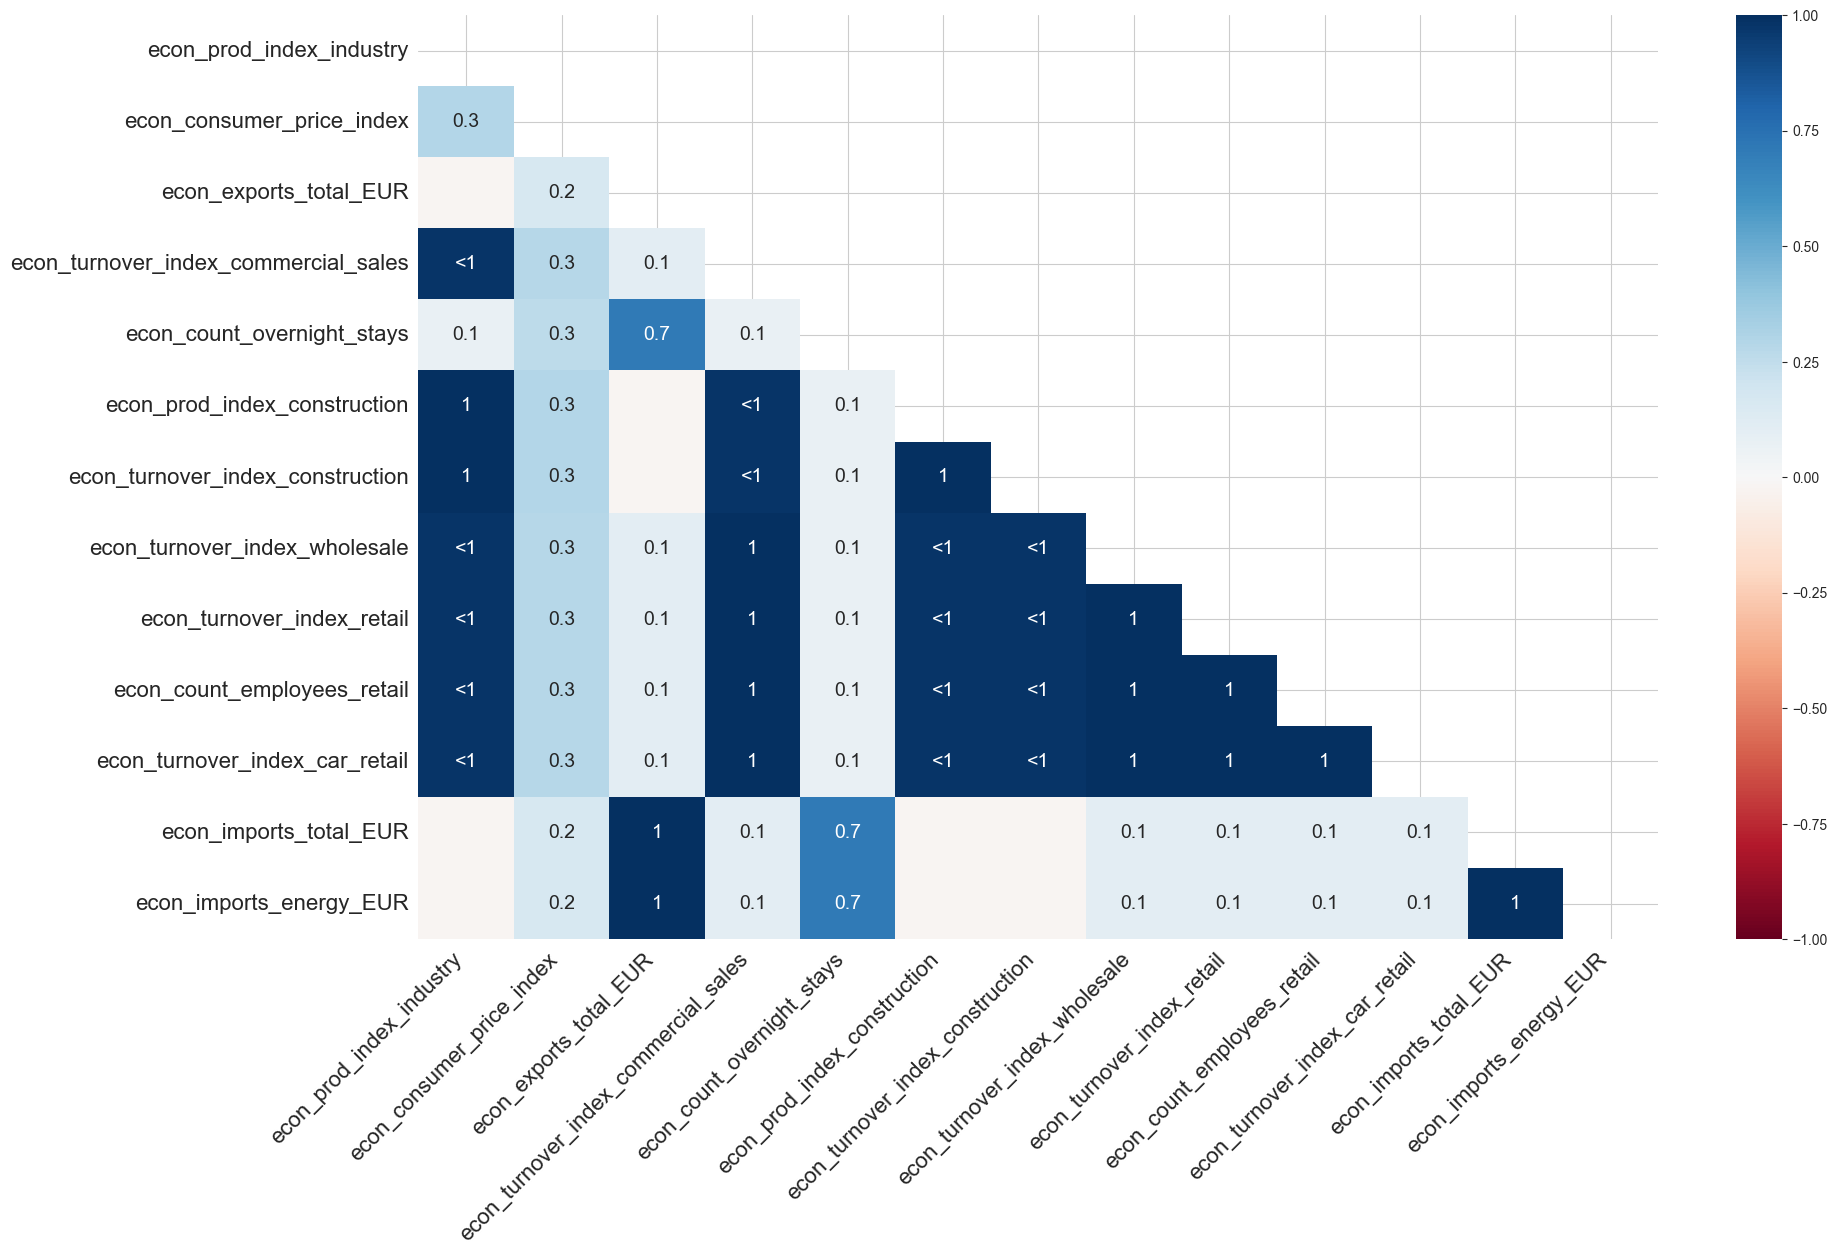

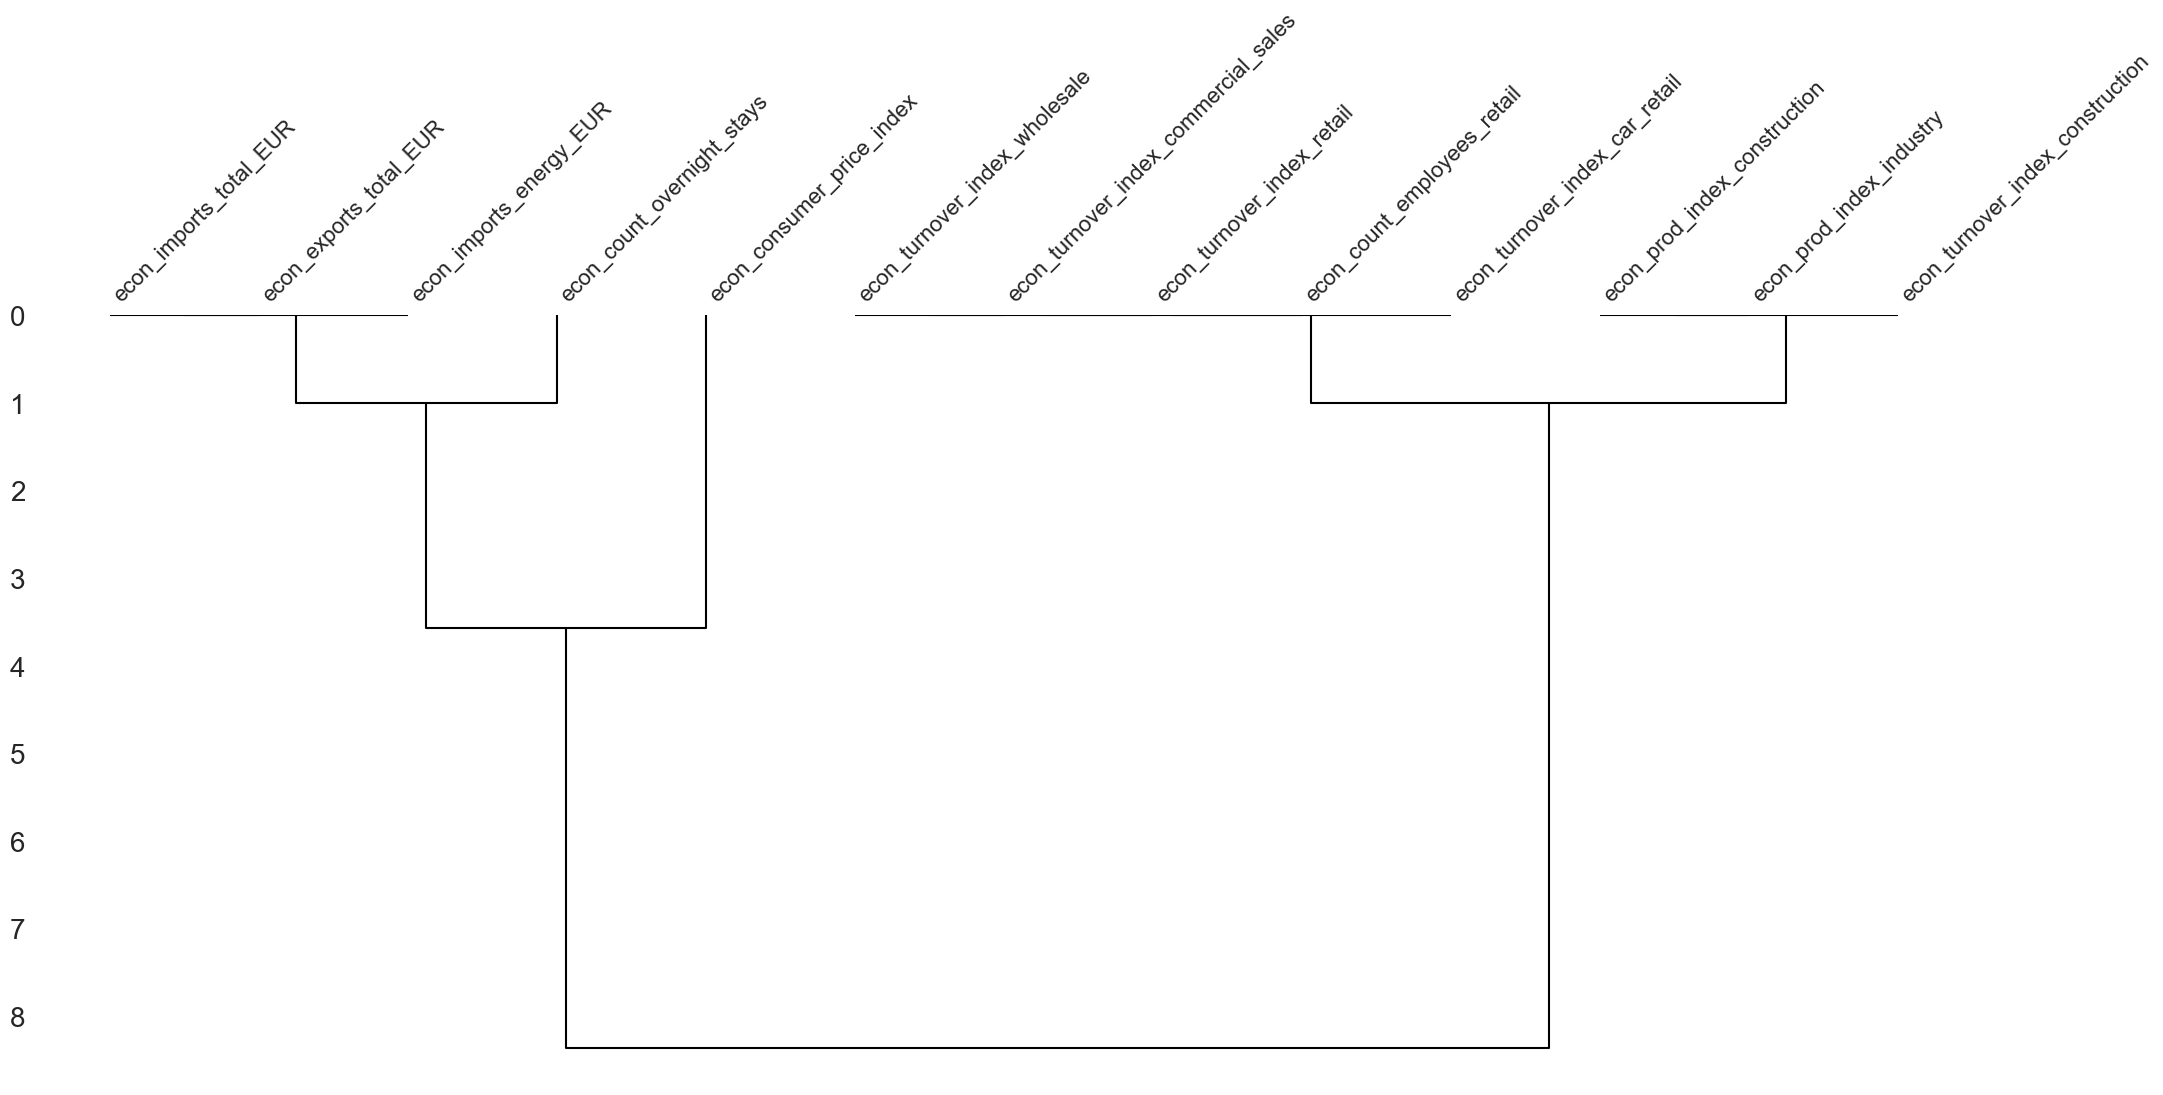

In [52]:
#economic data from Statistik Austria only
msno.matrix(df_econ, figsize=(7, 4))
msno.bar(df_econ)
msno.heatmap(df_econ)
msno.dendrogram(df_econ)

#only exports, overnight stays, imports and energy prices are complete
# consumer prices index are mostly complete
# all other columns will be dropped for the following reasons:
# 1. there are several complete columns available
# 54 months is not enough for a reliable time series model

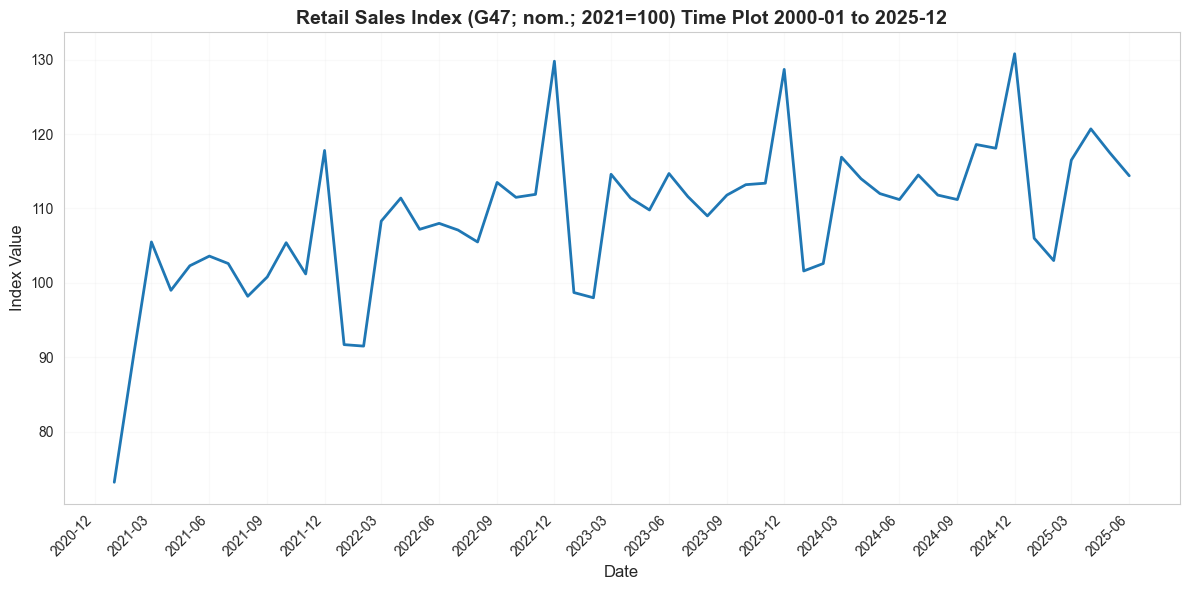

In [55]:
single_plot(df, 'econ_turnover_index_retail', all, 'monthly', meta_lib_path)

In [53]:
# DataFrame with Start- and Enddate of data availability
result = []
for col in df.columns:
    if col == 'date_dt':
        continue
    # find cels where value is not NaN
    non_na = df.loc[df[col].notna(), 'date_dt']
    if not non_na.empty:
        data_start = non_na.min()
        data_end = non_na.max()
    else:
        data_start = None
        data_end = None
    result.append({'column': col, 'data_start': data_start, 'data_end': data_end})

df_availability = pd.DataFrame(result).set_index('column')
display(df_availability)
df_availability.to_csv('../../data/processed/data_availability_overview.csv')
# availablilty overview saved as csv and copied into meta_data_library.xlsx manually


,data_start,data_end
column,,
date,2009-01-01,2025-09-01
year,2009-01-01,2025-09-01
month,2009-01-01,2025-09-01
quarter,2009-01-01,2025-09-01
week,2009-01-01,2025-09-01
...,...,...
price_combined,2015-01-01,2025-09-01
prod_renewable,2010-01-01,2025-07-01
prod_non_renewable,2010-01-01,2025-07-01


In [66]:
df_eda = df[
    (df['price_combined'].notna())
].copy()

cols_to_drop = [
    'price_exaa_mean', #already included in price_combined
    'price_mc_auction_mean', #already included in price_combined
    'price_count_exaa', #not necessary
    'price_count_mc', #not necessary
    'data_completeness', #not necessary
    'carbonprices_secondary_market', #carbonprices_primary market is complete, high correlation between the two
    'prod_geothermal_total', #mostly zero, possible data issues, certainly a confounding factor in modelling
    'econ_turnover_industry', #not enough data points, several other complete indicators available
    'econ_prod_index_industry', #not enough data points, several other complete indicators available
    'econ_turnover_index_commercial_sales', #not enough data points, several other complete indicators available
    'econ_prod_index_construction', #not enough data points, several other complete indicators available
    'econ_turnover_index_construction', #not enough data points, several other complete indicators available
    'econ_count_employees_industry', #not enough data points, several other complete indicators available
    'econ_count_employees_construction', #not enough data points, several other complete indicators available
    'econ_turnover_index_wholesale', #not enough data points, several other complete indicators available
    'econ_total_production_construction',#not enough data points, several other complete indicators available
    'econ_turnover_construction', #not enough data points, several other complete indicators available
    'econ_turnover_index_retail', #not enough data points, several other complete indicators available
    'econ_count_employees_retail', #not enough data points, several other complete indicators available
    'econ_turnover_index_car_retail' #not enough data points, several other complete indicators available
]

# DataFrame ohne diese Spalten abspeichern
df_eda.drop(columns=cols_to_drop, errors='ignore').to_csv('../../data/processed/data_analysis_ready.csv', index=False)
 
 